# Project Title
**Vanguard A/B Test Analysis:** Evaluating the Impact of a New Digital User Interface Business Context

Vanguard, one of the world's largest investment management companies, conducted an **A/B experiment** to evaluate whether a redesigned digital interface could improve the client experience during an online investment process. The redesigned interface introduced a more intuitive layout together with contextual prompts intended to guide users more efficiently through the completion process.

Clients participating in the experiment were randomly assigned to either the **Control Group**, which used the existing interface, or the **Test Group**, which interacted with the redesigned interface. The experiment was conducted between **15 March 2017 and 20 June 2017.**

As a data analyst in Vanguard's Customer Experience (CX) team, the objective is to determine whether the redesign produced measurable improvements in user behaviour and whether those improvements justify implementation from both a statistical and business perspective.

**Business Problem**

Although the redesigned interface was expected to improve the user experience, its effectiveness must be validated using data rather than assumptions.

This project seeks to answer the following business question:

- Did the redesigned interface significantly improve user completion rates and overall customer experience compared with the existing interface?
The answer will help Vanguard determine whether deploying the redesigned interface across all users is supported by statistical evidence and business value.

**Project Objectives**
The primary objectives of this analysis are to:

- Explore and clean the client demographic and behavioural datasets.
- Analyse user demographics and navigation behaviour.
- Calculate key performance indicators (KPIs) to measure user experience.
- Compare the performance of the Test and Control groups.
- Conduct hypothesis testing to determine whether observed differences are statistically significant.
- Evaluate whether the redesign satisfies Vanguard's 5% cost-effectiveness threshold.
- Provide data-driven recommendations for future product improvements.
- Project Methodology
  
**The analysis follows six major phases:**

- Data Collection and Integration
- Data Cleaning and Preparation
- Exploratory Data Analysis (EDA)
- Performance Metric Evaluation
- Statistical Hypothesis Testing
- Business Evaluation and Recommendations
- Business Questions

Throughout the project, the following questions will be investigated:

- Who are Vanguard's primary online clients?
- Which demographic groups use the digital platform most frequently?
- Does the redesigned interface increase the probability of users completing the process?
- Does the redesign reduce navigation errors?
- Does the redesign improve efficiency by reducing the time spent between process steps?
- Is the observed improvement large enough to justify implementation costs? -What recommendations can be made based on the experimental results?

# Datasets Used

The analysis combines three datasets supplied by Vanguard:

**Client Profiles**

Contains demographic information including age, tenure, gender, account balances, number of accounts, call history and login frequency.

**Digital Footprints**

Contains detailed clickstream information describing every interaction users performed throughout the digital process.

**Experiment Roster**

Identifies whether each client belonged to the Control or Test group.

These datasets are merged to produce a comprehensive view of user characteristics, behaviour and experimental outcomes.

**Statistical Approach**

The project combines descriptive statistics, probability, and inferential statistics to support evidence-based decision making.

**Descriptive Statistics**

Used to summarise client characteristics, behavioural patterns and process performance.

Examples include:

- Mean
- Median
- Standard deviation
- Frequency distributions
- Completion percentages
- Probability

Probability is central to evaluating user behaviour.

Several KPIs are interpreted as empirical probabilities.

For example,

- Completion Rate

P(Completion)= Total users Number of users reaching Confirm​

This represents the probability that a randomly selected client successfully completes the digital process.

Similarly,

Error Rate

P(Error)= Total Navigation Events Backward Navigation Events​

This estimates the probability that a randomly selected interaction contains user confusion or navigation errors.

These probabilities provide intuitive measures of customer behaviour and support informed business decisions.

Inferential Statistics

Descriptive statistics alone cannot determine whether differences between the Test and Control groups occurred by chance.

Therefore, inferential statistical methods are used to evaluate whether observed differences are statistically significant.

The analysis includes:

- Two-Proportion Z-Test
- Independent Samples T-Test
- Cost-effectiveness Threshold Test
- Confidence Intervals
- Effect Size Analysis

These methods allow conclusions to be generalized beyond the observed sample to the broader client population.

Expected Outcomes

By the end of this project, Vanguard will have a comprehensive evaluation of whether the redesigned interface:

- Improves process completion.
- Reduces navigation errors.
- Increases operational efficiency.
- Produces statistically significant improvements.
- Generates sufficient business value to justify implementation.

Import the core libraries used throughout the notebook: `pandas` for data handling, `matplotlib`/`seaborn` for plotting, `numpy` for numerical operations, and `requests` to test the data URLs.

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import streamlit as st
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.power import NormalIndPower
%matplotlib inline

## Setup and Data Loading

This section imports the libraries needed for the analysis, briefly tests that the data source is reachable, then loads all four datasets from GitHub into pandas dataframes for analysis.

Load all four raw datasets directly from the GitHub repository using their raw file URLs, so anyone on the team can run this notebook without changing local file paths. Each dataset is read into its own dataframe: client demographics, the two parts of the web activity log, and the experiment client roster.


In [118]:
df_final_demo = "https://raw.githubusercontent.com/winifredpaul/vanguard-ui-experiment-analysis/main/data/df_final_demo.txt"
df_final_web_data_pt_1 = "https://raw.githubusercontent.com/winifredpaul/vanguard-ui-experiment-analysis/main/data/df_final_web_data_pt_1.zip"
df_final_web_data_pt_2 = "https://raw.githubusercontent.com/winifredpaul/vanguard-ui-experiment-analysis/main/data/df_final_web_data_pt_2.zip"
df_final_experiment_clients = "https://raw.githubusercontent.com/winifredpaul/vanguard-ui-experiment-analysis/main/data/df_final_experiment_clients.txt"
clients_demo_df = pd.read_csv(df_final_demo)
web_data_pt1_df = pd.read_csv(df_final_web_data_pt_1, compression="zip")
web_data_pt2_df = pd.read_csv(df_final_web_data_pt_2, compression="zip")
experiment_clients_df = pd.read_csv(df_final_experiment_clients)

In [119]:
# Quick check that all four data URLs are reachable before loading them
for name, url in [
    ("df_final_demo", df_final_demo),
    ("df_final_web_data_pt_1", df_final_web_data_pt_1),
    ("df_final_web_data_pt_2", df_final_web_data_pt_2),
    ("df_final_experiment_clients", df_final_experiment_clients),
]:
    status = requests.head(url, allow_redirects=True).status_code
    print(f"{name}: HTTP {status}")

df_final_demo: HTTP 200
df_final_web_data_pt_1: HTTP 200
df_final_web_data_pt_2: HTTP 200
df_final_experiment_clients: HTTP 200


## Dataframe Reference

| Dataframe | Description |
|---|---|
| `clients_demo_df` | Raw client demographics — one row per client, including tenure, age, gender, account count, balance, and recent call/logon activity. |
| `web_data_pt1_df` | First half of the raw web activity log — one row per client interaction with the digital process (page views/steps). |
| `web_data_pt2_df` | Second half of the raw web activity log, sharing the same structure as `web_data_pt1_df`. |
| `experiment_clients_df` | Roster of clients and their assigned experiment group (`Test`, `Control`, or missing if not part of the experiment). |
| `clients_demo_exp_df` | `clients_demo_df` merged with `experiment_clients_df`, adding the `Variation` column and a `part_of_experiment` flag (`Yes`/`No`) for every client. |
| `experiment_only_df` | `clients_demo_exp_df` filtered down to only clients actually assigned to Test or Control (excludes non-participants). |
| `experiment_final_df` | `experiment_only_df` with rows containing missing values dropped — this is the **analysis-ready** client-level dataset for Phase 2/3 (KPIs, hypothesis testing). |
| `combined_web_data_df` | `web_data_pt1_df` and `web_data_pt2_df` combined (stacked) into a single web activity log, with duplicates removed and `date_time` converted to a proper datetime type. |
| `client_last_step` | One row per client, showing their most recently recorded process step and experiment group — built from `combined_web_data_df`. *(See the note on this dataframe below — it summarizes each client's last event overall, not per visit.)* |

**Note:** `client_last_step` currently identifies each client's furthest step based on their **most recent activity overall**, which may combine multiple separate visits into one summary row. For metrics like completion rate, we may want to revisit this at the **visit level** (`visit_id`) instead of the client level — see the "Spot-Checking Individual Client Histories" section for an example of why this matters.

## Analysing "df_final_demo" dataframe

This section performs an initial inspection of the client demographics dataset: checking data types and non-null counts, reviewing the unique values and distribution of the `gendr` column, checking for missing values and duplicate rows, reviewing summary statistics for the numeric columns, and isolating any rows with missing data for closer inspection.

In [120]:
# overview of the dataset
clients_demo_df.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [121]:
# Standardize column names for clarity
clients_demo_df = clients_demo_df.rename(
    columns={
        "clnt_tenure_yr": "client_tenure_year",
        "clnt_tenure_mnth": "client_tenure_months",
        "clnt_age": "client_age",
        "gendr": "gender",
        "num_accts": "number_of_accounts",
        "bal": "balance",
        "calls_6_mnth": "calls_last_6_months",
        "logons_6_mnth": "logons_last_6_months",
    }
)

In [122]:
# Check data types and non-null counts for each column
clients_demo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_id             70609 non-null  int64  
 1   client_tenure_year    70595 non-null  float64
 2   client_tenure_months  70595 non-null  float64
 3   client_age            70594 non-null  float64
 4   gender                70595 non-null  object 
 5   number_of_accounts    70595 non-null  float64
 6   balance               70595 non-null  float64
 7   calls_last_6_months   70595 non-null  float64
 8   logons_last_6_months  70595 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 4.8+ MB


In [123]:
# Count missing values in each column
clients_demo_df.isnull().sum()

client_id                0
client_tenure_year      14
client_tenure_months    14
client_age              15
gender                  14
number_of_accounts      14
balance                 14
calls_last_6_months     14
logons_last_6_months    14
dtype: int64

In [124]:
# Isolate rows that have any missing values, for closer inspection
clients_demo_df[clients_demo_df.isnull().any(axis=1)]

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [125]:
# Check for fully duplicated rows (all columns identical)
clients_demo_df.duplicated().sum()

np.int64(0)

In [126]:
# Check for duplicate client IDs specifically (different from full-row duplicates)
clients_demo_df["client_id"].duplicated().sum()

np.int64(0)

In [127]:
# Check the distinct values in the gendr column
clients_demo_df["gender"].unique()

array(['U', 'M', 'F', nan, 'X'], dtype=object)

In [128]:
# Check how many clients fall into each gender category
clients_demo_df["gender"].value_counts()

gender
U    24122
M    23724
F    22746
X        3
Name: count, dtype: int64

In [129]:
# Review summary statistics (mean, min, max, quartiles) for the numeric columns
clients_demo_df.describe()

,client_id,client_tenure_year,client_tenure_months,client_age,number_of_accounts,balance,calls_last_6_months,logons_last_6_months
count,7.060900e+04,70595.000000,70595.000000,70594.000000,70595.000000,7.059500e+04,70595.000000,70595.000000
mean,5.004992e+06,12.052950,150.659367,46.442240,2.255528,1.474452e+05,3.382478,5.566740
std,2.877278e+06,6.871819,82.089854,15.591273,0.534997,3.015087e+05,2.236580,2.353286
min,1.690000e+02,2.000000,33.000000,13.500000,1.000000,1.378942e+04,0.000000,1.000000
25%,2.519329e+06,6.000000,82.000000,32.500000,2.000000,3.734683e+04,1.000000,4.000000
50%,5.016978e+06,11.000000,136.000000,47.000000,2.000000,6.333290e+04,3.000000,5.000000
75%,7.483085e+06,16.000000,192.000000,59.000000,2.000000,1.375449e+05,6.000000,7.000000
max,9.999839e+06,62.000000,749.000000,96.000000,8.000000,1.632004e+07,7.000000,9.000000


In [130]:
# Look at the youngest clients to check the age data makes sense
clients_demo_df.sort_values("client_age").head()

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months
70216,5417612,4.0,59.0,13.5,U,2.0,24435.08,7.0,7.0
67700,6250331,4.0,59.0,14.0,U,2.0,19945.35,3.0,3.0
58281,3677152,22.0,273.0,14.0,F,2.0,16989.14,1.0,1.0
51837,4226013,5.0,65.0,14.5,U,3.0,32835.33,5.0,5.0
63598,49451,14.0,178.0,14.5,M,2.0,15487.91,2.0,2.0


`client_tenure_year` is a rounded-down (floored) version of `client_tenure_months ÷ 12`, not an independently recorded value — confirmed by comparing `client_tenure_months // 12` against `client_tenure_year`, which match exactly. This isn't a data quality issue; it just means `client_tenure_months` is the more precise field to use for any tenure-based calculations going forward.

In [131]:
# Check if clnt_tenure_yr = floor(clnt_tenure_mnth / 12)
clients_demo_df["tenure_check_correct"] = (clients_demo_df["client_tenure_months"] // 12)

clients_demo_df[["client_tenure_year", "client_tenure_months", "tenure_check_correct"]].head(10)

,client_tenure_year,client_tenure_months,tenure_check_correct
0,6.0,73.0,6.0
1,7.0,94.0,7.0
2,5.0,64.0,5.0
3,16.0,198.0,16.0
4,12.0,145.0,12.0
5,5.0,71.0,5.0
6,5.0,66.0,5.0
7,30.0,361.0,30.0
8,30.0,369.0,30.0
9,15.0,189.0,15.0


## Analysing "df_final_web_data_pt_1" dataframe

This section performs an initial inspection of the first web activity file: checking data types and non-null counts, missing values, and duplicate rows, previewing the first few rows to understand the structure of the data, confirming the distinct process steps match the expected funnel stages (start, step_1, step_2, step_3, confirm), checking how many unique visitors and sessions are captured, and reviewing the date range covered which is establishing a baseline to sanity-check against once this file is combined with web_data_pt2_df.

In [132]:
web_data_pt1_df.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [133]:
# Check data types and non-null counts for the first web activity file
web_data_pt1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 343141 entries, 0 to 343140
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     343141 non-null  int64 
 1   visitor_id    343141 non-null  object
 2   visit_id      343141 non-null  object
 3   process_step  343141 non-null  object
 4   date_time     343141 non-null  object
dtypes: int64(1), object(4)
memory usage: 13.1+ MB


In [134]:
# Check for missing values
web_data_pt1_df.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [135]:
# Check for fully duplicated rows
web_data_pt1_df.duplicated().sum()

np.int64(2095)

In [136]:
# Preview the first few rows to understand the structure of the web activity log
web_data_pt1_df.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


In [137]:
# Check the distinct process steps to confirm the expected funnel stages
web_data_pt1_df["process_step"].unique()

array(['step_3', 'step_2', 'step_1', 'start', 'confirm'], dtype=object)

In [138]:
# Check how many unique visitors and sessions are captured in this file
print("Unique visitors:", web_data_pt1_df["visitor_id"].nunique())
print("Unique visits:", web_data_pt1_df["visit_id"].nunique())

Unique visitors: 62936
Unique visits: 75256


In [139]:
# Check the date range covered by this file
web_data_pt1_df["date_time"] = pd.to_datetime(web_data_pt1_df["date_time"])
print("First activity:", web_data_pt1_df["date_time"].min())
print("Last activity:", web_data_pt1_df["date_time"].max())

First activity: 2017-03-15 00:03:03
Last activity: 2017-04-30 23:59:16


## Analysing "df_final_web_data_pt_2" dataframe

This section performs an initial inspection of the second web activity file: checking data types and non-null counts, missing values, and duplicate rows, previewing the first few rows to confirm it matches pt_1's structure, confirming the distinct process steps align with the same funnel stages **(start, step_1, step_2, step_3, confirm),** checking how many unique visitors and sessions are captured, and reviewing the date range covered. Finally, the columns of both files are compared directly to confirm they match exactly before combining them with pd.concat().

In [140]:
# overview of the dataset
web_data_pt2_df.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [141]:
# Check data types and non-null counts for the second web activity file
web_data_pt2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412264 entries, 0 to 412263
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   client_id     412264 non-null  int64 
 1   visitor_id    412264 non-null  object
 2   visit_id      412264 non-null  object
 3   process_step  412264 non-null  object
 4   date_time     412264 non-null  object
dtypes: int64(1), object(4)
memory usage: 15.7+ MB


In [142]:
# Check for missing values
web_data_pt2_df.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

In [143]:
# Check for fully duplicated rows
web_data_pt2_df.duplicated().sum()

np.int64(8669)

In [144]:
# Preview the first few rows to confirm this file matches pt_1's structure
web_data_pt2_df.head()

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58


In [145]:
# Check the distinct process steps match pt_1's funnel stages
web_data_pt2_df["process_step"].unique()

array(['confirm', 'step_3', 'step_2', 'step_1', 'start'], dtype=object)

In [146]:
# Check how many unique visitors and sessions are captured in this file
print("Unique visitors:", web_data_pt2_df["visitor_id"].nunique())
print("Unique visits:", web_data_pt2_df["visit_id"].nunique())

Unique visitors: 71042
Unique visits: 82841


In [147]:
# Check the date range covered by this file
web_data_pt2_df["date_time"] = pd.to_datetime(web_data_pt2_df["date_time"])
print("First activity:", web_data_pt2_df["date_time"].min())
print("Last activity:", web_data_pt2_df["date_time"].max())

First activity: 2017-05-01 00:00:26
Last activity: 2017-06-20 23:59:57


In [148]:
# Confirm both web data files have identical columns, in the same order,
# before combining them with pd.concat()
list(web_data_pt1_df.columns) == list(web_data_pt2_df.columns)

True

## Analysing "df_final_experiment_clients" dataframe

This section performs an initial inspection of the experiment roster: checking data types and non-null counts, missing values in the Variation column (clients with no assignment weren't part of the experiment), full-row and duplicate client_id checks to confirm each client appears only once, the distinct values of Variation (Test, Control, or missing), and the count of clients in each group.

In [149]:
# Check data types and non-null counts for the experiment roster
experiment_clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  70609 non-null  int64 
 1   Variation  50500 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.1+ MB


In [150]:
# Check for missing Variation values (clients not part of the experiment)
experiment_clients_df.isnull().sum()

client_id        0
Variation    20109
dtype: int64

In [151]:
# Check for fully duplicated rows
experiment_clients_df.duplicated().sum()

np.int64(0)

In [152]:
# Check for duplicate client IDs in the roster
experiment_clients_df["client_id"].duplicated().sum()

np.int64(0)

In [153]:
# Standardize column names
experiment_clients_df = experiment_clients_df.rename(
    columns={"Variation": "variation"}
)
# verify the changes
print(experiment_clients_df.columns)

Index(['client_id', 'variation'], dtype='object')


In [154]:
# Confirm the only possible values are Test, Control, or missing
experiment_clients_df["variation"].unique()

array(['Test', 'Control', nan], dtype=object)

In [155]:
# Check how many clients are in each experiment group
experiment_clients_df["variation"].value_counts(dropna=False)

variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

## Merging Client Demographic file with Clients who were part of experiment file

This step checks how many clients overlap between the two datasets before merging them.

- First, it counts the total number of unique clients in the demographics file (`clients_demo_df`).
- Then, it counts how many clients were actually assigned to a Test or Control group in the experiment file (ignoring clients with no assignment, i.e. `Variation` is blank).
- Next, it merges the two files together on `client_id`, keeping only clients that appear in both datasets (an "inner" merge).
- From that merged result, it counts how many of those overlapping clients also have a valid experiment assignment (Test or Control).
- Finally, it prints all three numbers side by side, so we can sanity-check that the overlap makes sense before doing the real merge in the next step.

This is a validation check, not the actual merge used later — its purpose is to confirm the two datasets line up correctly (e.g. that most/all demo clients also appear in the experiment file) before we commit to merging them for real.

In [156]:
# STEP 1: Count unique clients in dataset 1
dataset_1_clients = clients_demo_df["client_id"].nunique()

# STEP 2: Count unique clients assigned to the experiment (exclude NaN)
dataset_4_clients = (
    experiment_clients_df
    .loc[experiment_clients_df["variation"].notna(), "client_id"]
    .nunique()
)

# STEP 3: Find clients appearing in both datasets
overlapping_clients = clients_demo_df.merge(
    experiment_clients_df,
    on="client_id",
    how="inner"
)

# STEP 4: Count unique overlapping clients who participated in the experiment
overlap_count = (
    overlapping_clients
    .loc[overlapping_clients["variation"].notna(), "client_id"]
    .nunique()
)

# STEP 5: Display the results
print("Unique clients in dataset 1:", dataset_1_clients)
print("Unique experiment clients:", dataset_4_clients)
print("Clients appearing in both datasets:", overlap_count)

# STEP 6: Preview the overlapping clients
overlapping_clients.head(10)

Unique clients in dataset 1: 70609
Unique experiment clients: 50500
Clients appearing in both datasets: 50500


,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months,tenure_check_correct,variation
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,6.0,Test
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,7.0,Control
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,5.0,Test
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,16.0,Test
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,12.0,Control
5,3727881,5.0,71.0,30.5,U,2.0,23915.60,0.0,3.0,5.0,Control
6,272934,5.0,66.0,58.5,U,2.0,27021.42,2.0,5.0,5.0,Control
7,388801,30.0,361.0,57.5,M,5.0,522498.72,1.0,4.0,30.0,Test
8,285619,30.0,369.0,67.5,M,2.0,299388.72,3.0,6.0,30.0,Control
9,8198645,15.0,189.0,54.5,F,2.0,382303.83,6.0,9.0,15.0,Test


Now that the overlap has been validated, this step performs the real merge: it adds the `Variation` column from the experiment roster onto the client demographics dataset, using a left join so that every client from the demographics file is kept, whether or not they were part of the experiment.

A new column, `part_of_experiment`, is then created from `Variation`: it's marked `"Yes"` if the client has a Test/Control assignment, and `"No"` if `Variation` is blank (meaning they weren't included in the experiment). This flag makes it easy to filter down to experiment-only clients in later steps.

In [157]:
# Merge the Variation column from the experiment roster into the demo dataset
# Using a left join keeps every client, whether or not they were part of the experiment
clients_demo_exp_df = clients_demo_df.merge(
    experiment_clients_df[["client_id", "variation"]],
    on="client_id",
    how="left"
)

# Flag whether each client was part of the experiment
clients_demo_exp_df["part_of_experiment"] = clients_demo_exp_df["variation"].notna().map({
    True: "Yes",
    False: "No"
})

clients_demo_exp_df.head()

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months,tenure_check_correct,variation,part_of_experiment
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,6.0,Test,Yes
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,7.0,Control,Yes
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,5.0,Test,Yes
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,16.0,Test,Yes
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,12.0,Control,Yes


In [158]:
# Confirm structure and non-null counts after the merge
clients_demo_exp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_id             70609 non-null  int64  
 1   client_tenure_year    70595 non-null  float64
 2   client_tenure_months  70595 non-null  float64
 3   client_age            70594 non-null  float64
 4   gender                70595 non-null  object 
 5   number_of_accounts    70595 non-null  float64
 6   balance               70595 non-null  float64
 7   calls_last_6_months   70595 non-null  float64
 8   logons_last_6_months  70595 non-null  float64
 9   tenure_check_correct  70595 non-null  float64
 10  variation             50500 non-null  object 
 11  part_of_experiment    70609 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 6.5+ MB


In [159]:
# Check how many clients fall into each group, including those not in the experiment
clients_demo_exp_df["variation"].value_counts(dropna=False)

variation
Test       26968
Control    23532
NaN        20109
Name: count, dtype: int64

In [160]:
# Check gender distribution across Test/Control/not-in-experiment groups
gender_by_variation = pd.crosstab(
    clients_demo_exp_df["variation"],
    clients_demo_exp_df["gender"]
)
print(gender_by_variation)

gender        F     M     U  X
variation                     
Control    7543  7970  8014  0
Test       8716  8977  9266  2


### Identifying Clients Participating in the A/B Experiment

To determine which clients were included in the A/B test, the client demographics dataset (clients_demo_df) was merged with the experiment roster (experiment_clients_df) using the client_id field.

The `Variation` column from the experiment dataset was added to the demographics dataset, indicating whether each client belonged to the **Test** group, **Control** group, or was **not part of the experiment** (`NaN`).

A new boolean column, `part_of_experiment`, was then created:

- **True** → Client participated in the A/B experiment (assigned to either the Test or Control group).
- **False** → Client was not included in the experiment.

This flag simplifies filtering the dataset for subsequent analyses, such as calculating performance metrics, comparing completion rates, and conducting hypothesis testing using only the experimental population.

## Combining the two web data files

In [161]:
# Stack the two web activity files into one (they share identical columns)
combined_web_data_df = pd.concat(
    [web_data_pt1_df, web_data_pt2_df],
    ignore_index=True
)

combined_web_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     755405 non-null  int64         
 1   visitor_id    755405 non-null  object        
 2   visit_id      755405 non-null  object        
 3   process_step  755405 non-null  object        
 4   date_time     755405 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 28.8+ MB


In [162]:
# Check for duplicate rows introduced by combining the two files
combined_web_data_df.duplicated().sum()

np.int64(10764)

In [163]:
# Remove duplicate rows so events aren't double-counted downstream
combined_web_data_df = combined_web_data_df.drop_duplicates()

# Confirm no duplicates remain
combined_web_data_df.duplicated().sum()

np.int64(0)

In [164]:
# Confirm the combined file still only has the expected funnel stages
combined_web_data_df["process_step"].unique()

array(['step_3', 'step_2', 'step_1', 'start', 'confirm'], dtype=object)

In [165]:
# Convert date_time to a proper datetime type
combined_web_data_df["date_time"] = pd.to_datetime(combined_web_data_df["date_time"])

In [166]:
combined_web_data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 744641 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     744641 non-null  int64         
 1   visitor_id    744641 non-null  object        
 2   visit_id      744641 non-null  object        
 3   process_step  744641 non-null  object        
 4   date_time     744641 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 34.1+ MB


In [167]:
# Check the overall date range and confirm all activity falls within the experiment window
print("First activity:", combined_web_data_df["date_time"].min())
print("Last activity:", combined_web_data_df["date_time"].max())

experiment_start = pd.Timestamp("2017-03-15")
experiment_end = pd.Timestamp("2017-06-21")

outside_experiment = combined_web_data_df[
    (combined_web_data_df["date_time"] < experiment_start) | (combined_web_data_df["date_time"] > experiment_end)
]

print(f"\nActivities outside the experiment period: {len(outside_experiment)}")
outside_experiment.tail()

First activity: 2017-03-15 00:03:03
Last activity: 2017-06-20 23:59:57

Activities outside the experiment period: 0


,client_id,visitor_id,visit_id,process_step,date_time


In [168]:
# Spot-check one client's full activity history, sorted chronologically
client_id = 934

(
    combined_web_data_df[combined_web_data_df["client_id"] == client_id]
    .sort_values("date_time")
)

,client_id,visitor_id,visit_id,process_step,date_time
62623,934,810392784_45004760546,7076463_57954418406_971348,start,2017-04-18 02:36:30
62622,934,810392784_45004760546,7076463_57954418406_971348,start,2017-04-18 02:37:02
62621,934,810392784_45004760546,7076463_57954418406_971348,start,2017-04-18 02:38:24
62620,934,810392784_45004760546,7076463_57954418406_971348,start,2017-04-18 02:38:52


In [169]:
# Spot-check a client who completed the process (reached "confirm")
# Useful to confirm their last row really does show process_step = "confirm"
client_id = combined_web_data_df.loc[
    combined_web_data_df["process_step"] == "confirm", "client_id"
].iloc[0]

(
    combined_web_data_df[combined_web_data_df["client_id"] == client_id]
    .sort_values("date_time")
)

,client_id,visitor_id,visit_id,process_step,date_time
12,8320017,39393514_33118319366,960651974_70596002104_312201,start,2017-04-05 13:08:06
11,8320017,39393514_33118319366,960651974_70596002104_312201,step_1,2017-04-05 13:08:24
10,8320017,39393514_33118319366,960651974_70596002104_312201,step_2,2017-04-05 13:08:40
9,8320017,39393514_33118319366,960651974_70596002104_312201,step_3,2017-04-05 13:09:43
8,8320017,39393514_33118319366,960651974_70596002104_312201,confirm,2017-04-05 13:10:05


In [170]:
# Spot-check a client with multiple visits (visit_id changes),
# to see how groupby("client_id").last() behaves when someone has more than one session
multi_visit_clients = (
    combined_web_data_df.groupby("client_id")["visit_id"].nunique()
)
client_id = multi_visit_clients[multi_visit_clients > 1].index[0]

(
    combined_web_data_df[combined_web_data_df["client_id"] == client_id]
    .sort_values("date_time")
)

,client_id,visitor_id,visit_id,process_step,date_time
594421,805,831412807_82548325803,905546080_75813398358_250101,start,2017-06-08 01:10:29
594420,805,831412807_82548325803,905546080_75813398358_250101,step_1,2017-06-08 01:11:49
594431,805,831412807_82548325803,451173196_11661340552_563345,start,2017-06-15 19:09:13
594430,805,831412807_82548325803,451173196_11661340552_563345,step_1,2017-06-15 19:09:19
594429,805,831412807_82548325803,451173196_11661340552_563345,step_2,2017-06-15 19:09:26
594428,805,831412807_82548325803,451173196_11661340552_563345,step_2,2017-06-15 19:11:21
594427,805,831412807_82548325803,451173196_11661340552_563345,start,2017-06-15 19:11:28
594491,805,831412807_82548325803,72221519_52513154978_430287,start,2017-06-17 19:23:17
594490,805,831412807_82548325803,72221519_52513154978_430287,step_1,2017-06-17 19:23:20


## Determining the Furthest Step Reached per Client

Since clients can navigate back and forth between steps, we can't rely on their most recent chronological event to determine whether they completed the process — a client's very last recorded action might be an earlier step from a separate session. Instead, this section ranks each process step numerically and finds the highest rank each client ever reached, which more accurately reflects true completion.

The result is merged into `clients_demo_exp_df`, so completion status is available alongside each client's demographics and experiment group.

In [171]:
# Define the order of the process, so we can measure "furthest step reached"
step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

# Map each process_step to its numeric rank
combined_web_data_df["step_rank"] = combined_web_data_df["process_step"].map(step_order)

# For each client, find the highest step rank they ever reached
furthest_step = (
    combined_web_data_df
    .groupby("client_id")["step_rank"]
    .max()
    .reset_index()
)

# Map the numeric rank back to a readable step name
rank_to_step = {v: k for k, v in step_order.items()}
furthest_step["furthest_step_reached"] = furthest_step["step_rank"].map(rank_to_step)

furthest_step.head()

,client_id,step_rank,furthest_step_reached
0,169,4,confirm
1,336,0,start
2,546,4,confirm
3,555,4,confirm
4,647,4,confirm


In [172]:
# Merge the furthest step reached into the demographics + experiment dataframe
clients_demo_exp_df = clients_demo_exp_df.merge(
    furthest_step[["client_id", "furthest_step_reached"]],
    on="client_id",
    how="left"
)

clients_demo_exp_df.head()

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months,tenure_check_correct,variation,part_of_experiment,furthest_step_reached
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,6.0,Test,Yes,confirm
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,7.0,Control,Yes,confirm
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,5.0,Test,Yes,step_3
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,16.0,Test,Yes,start
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,12.0,Control,Yes,start


In [173]:
# Keep only clients who were actually assigned to Test or Control
experiment_only_df = clients_demo_exp_df[
    clients_demo_exp_df["variation"].isin(["Test", "Control"])
].copy()

# Drop the participation flag — every row here is an experiment client by definition
experiment_only_df = experiment_only_df.drop(columns=["part_of_experiment"])

experiment_only_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 50500 entries, 0 to 50499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              50500 non-null  int64  
 1   client_tenure_year     50488 non-null  float64
 2   client_tenure_months   50488 non-null  float64
 3   client_age             50487 non-null  float64
 4   gender                 50488 non-null  object 
 5   number_of_accounts     50488 non-null  float64
 6   balance                50488 non-null  float64
 7   calls_last_6_months    50488 non-null  float64
 8   logons_last_6_months   50488 non-null  float64
 9   tenure_check_correct   50488 non-null  float64
 10  variation              50500 non-null  object 
 11  furthest_step_reached  50500 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 5.0+ MB


In [174]:
experiment_only_df.head()

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months,tenure_check_correct,variation,furthest_step_reached
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,6.0,Test,confirm
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0,7.0,Control,confirm
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0,5.0,Test,step_3
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0,16.0,Test,start
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0,12.0,Control,start


In [175]:
# Confirm the Test/Control split
experiment_only_df["variation"].value_counts(dropna=False)

variation
Test       26968
Control    23532
Name: count, dtype: int64

In [176]:
# Inspect rows with missing demographic data before dropping them
missing_rows = experiment_only_df[experiment_only_df.isnull().any(axis=1)]
missing_rows

,client_id,client_tenure_year,client_tenure_months,client_age,gender,number_of_accounts,balance,calls_last_6_months,logons_last_6_months,tenure_check_correct,variation,furthest_step_reached
4164,7402828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,confirm
8316,355337,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,confirm
8677,8412164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test,step_2
9583,4666211,8.0,106.0,NaN,F,2.0,42550.55,4.0,7.0,8.0,Control,confirm
13444,2222915,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test,step_1
18066,4876926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test,confirm
25961,5277910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test,confirm
28432,7616759,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,confirm
35323,8191345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control,confirm
43518,1227228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Test,confirm


In [177]:
# Drop rows with missing values — this is the analysis-ready experiment dataset
experiment_final_df = experiment_only_df.dropna()

experiment_final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50487 entries, 0 to 50499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              50487 non-null  int64  
 1   client_tenure_year     50487 non-null  float64
 2   client_tenure_months   50487 non-null  float64
 3   client_age             50487 non-null  float64
 4   gender                 50487 non-null  object 
 5   number_of_accounts     50487 non-null  float64
 6   balance                50487 non-null  float64
 7   calls_last_6_months    50487 non-null  float64
 8   logons_last_6_months   50487 non-null  float64
 9   tenure_check_correct   50487 non-null  float64
 10  variation              50487 non-null  object 
 11  furthest_step_reached  50487 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 5.0+ MB


## Latest Client Process Step and Experiment Assignment

This analysis consolidates the web activity data to a client-level view by identifying the most recent interaction recorded for each client. The web activity dataset is first sorted chronologically, ensuring that the latest event for each client appears last in their activity history. The data is then grouped by `client_id`, and the final record for each client is retained, representing the furthest process step reached by that client.

The resulting dataset is enriched with experiment information by joining it with the experiment client dataset on `client_id`. This adds the `Variation` field, allowing each client to be classified into the corresponding experimental group (e.g., Test or Control).

As a validation step, individual client histories can be inspected by filtering the web activity dataset for a specific `client_id` and sorting the records by timestamp. This confirms that the process step retained in the final client-level dataset corresponds to the client's last recorded activity.

In [178]:
# Sort chronologically so each client's most recent event is last
combined_web_data_df = combined_web_data_df.sort_values("date_time")

# Get each client's latest recorded event
client_last_step = (
    combined_web_data_df
    .groupby("client_id")
    .last()
    .reset_index()
)

# Add each client's experiment group assignment
client_last_step = client_last_step.merge(
    experiment_clients_df[["client_id", "variation"]],
    on="client_id",
    how="left"
)

client_last_step[["client_id", "process_step", "variation"]].head(20)

,client_id,process_step,variation
0,169,confirm,NaN
1,336,start,NaN
2,546,confirm,NaN
3,555,confirm,Test
4,647,confirm,Test
5,722,confirm,NaN
6,786,confirm,NaN
7,805,step_1,NaN
8,832,confirm,NaN
9,934,start,Test


In [179]:
web_events_df = combined_web_data_df.merge(
    experiment_clients_df[["client_id", "variation"]],
    on="client_id",
    how="inner"
)

web_events_df = web_events_df[
    web_events_df["variation"].isin(["Test", "Control"])
].reset_index(drop=True)

print(web_events_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 317235 entries, 0 to 317234
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     317235 non-null  int64         
 1   visitor_id    317235 non-null  object        
 2   visit_id      317235 non-null  object        
 3   process_step  317235 non-null  object        
 4   date_time     317235 non-null  datetime64[ns]
 5   step_rank     317235 non-null  int64         
 6   variation     317235 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 16.9+ MB
None


In [180]:
group_sizes = (
    web_events_df.drop_duplicates(subset=["client_id"])["variation"]
    .value_counts()
)
group_sizes

variation
Test       26968
Control    23532
Name: count, dtype: int64

In [181]:
# 1. Event_Level dataset
clients_df = experiment_final_df.copy()

clients_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 50487 entries, 0 to 50499
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   client_id              50487 non-null  int64  
 1   client_tenure_year     50487 non-null  float64
 2   client_tenure_months   50487 non-null  float64
 3   client_age             50487 non-null  float64
 4   gender                 50487 non-null  object 
 5   number_of_accounts     50487 non-null  float64
 6   balance                50487 non-null  float64
 7   calls_last_6_months    50487 non-null  float64
 8   logons_last_6_months   50487 non-null  float64
 9   tenure_check_correct   50487 non-null  float64
 10  variation              50487 non-null  object 
 11  furthest_step_reached  50487 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 5.0+ MB


In [182]:
clients_df.count()

client_id                50487
client_tenure_year       50487
client_tenure_months     50487
client_age               50487
gender                   50487
number_of_accounts       50487
balance                  50487
calls_last_6_months      50487
logons_last_6_months     50487
tenure_check_correct     50487
variation                50487
furthest_step_reached    50487
dtype: int64

# Phase 1 — Exploratory Data Analysis (EDA)

This section explores the demographics and behavioral patterns of Vanguard’s online clients. Understanding who the clients are and how they behave online helps us interpret the A/B test results more accurately.  This helps us identify whether the Test and Control groups are comparable and whether certain demographic or behavioral factors may influence completion rates.


We will examine:

**Demograpics:**

- Age distribution

- Gender distribution

- Tenure with Vanguard

**Account characteristics:**

- Number of accounts

- Account balances

**Engagement behavior:**

- Logons

- calls 

These insights provide context for interpreting the experiment results and identifying potential biases or segmentation effects.


In [183]:
# 1. Age Distribution
clients_df["client_age"].describe()

count    50487.000000
mean        47.319795
std         15.518616
min         17.000000
25%         33.500000
50%         48.000000
75%         59.500000
max         96.000000
Name: client_age, dtype: float64

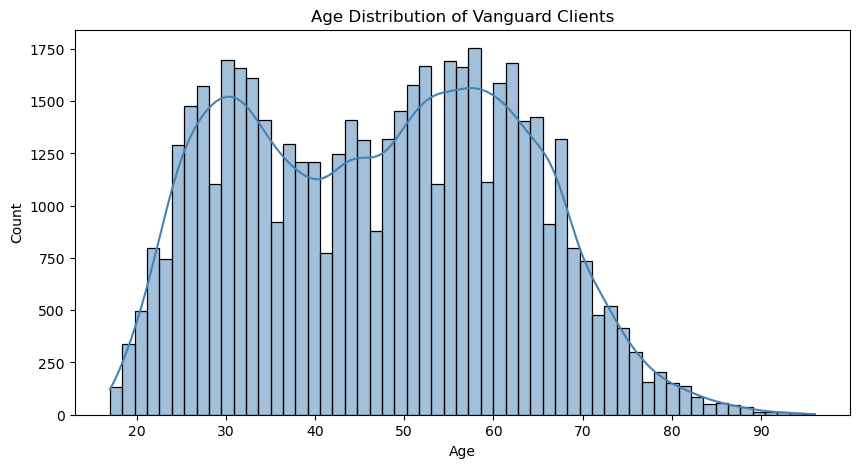

In [184]:
# Ploting Age Distribution

plt.figure(figsize=(10,5))
sns.histplot(clients_df["client_age"], kde=True, color="steelblue")
plt.title("Age Distribution of Vanguard Clients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


# Age Distribution
The age distribution shows how Vanguard’s online clients are spread across different age groups.

The graph shows a bimodal age distribution. There are two distinct primary groups of clients using Vanguard's services rather than just a single average age group.

The **first major peak** occurs around **30 to 35 years old**, representing a strong segment of younger, tech-adopting or early-career digital investors(*Younger Adult Cohort*)

The **second and laargest peak** is concentrated between **55 and 60 years old**, representing mature investors or individuals nearing or entering retirement age (*Middle_Aged to Older Adult Cohort*).

**Key insights to highlight:**
- Vanguard clients tend to be **middle‑aged to older adults**, which is typical for investment platforms.
- If the distribution is skewed toward older ages, this may influence:
  - Comfort with digital interfaces
  - Completion rates
  - Time spent on each step

Understanding age distribution helps us later evaluate whether the Test and Control groups are balanced.

In [185]:
# Gender Distribution

clients_df["gender"].value_counts()

gender
U    17280
M    16947
F    16258
X        2
Name: count, dtype: int64

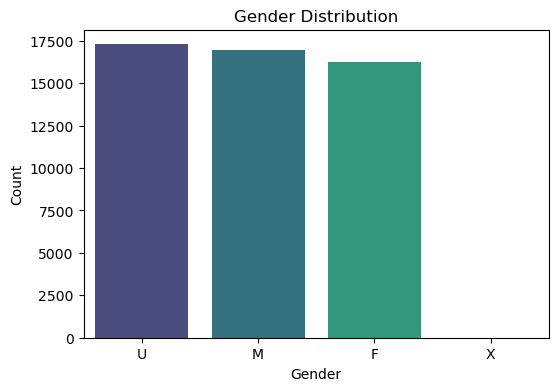

In [186]:
# Ploting the gender distribution graph

plt.figure(figsize=(6,4))
sns.countplot(data=clients_df, x="gender", hue="gender", palette="viridis", legend=False)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


##  Gender Distribution

This chart shows four gender classifications in the dataset: **U**(Unknown/Unspecified), **M**(male), **F**(female), and **X**(Non-binary/Other) clients.

Points to consider:
- Eventhough, U is has higher figures (with roughly **17,300+clients**), Vanguard’s client base may be male‑dominated(behind at around **16,800+clients**) due to historical investment trends. Female is slightly lower at approximately **16,000+clients**. **X** has a negligible or near_zero count in comparison.
- Gender differences could influence:
  - Digital behavior
  - Completion rates
  - Engagement with the redesigned interface

We will later check whether gender distribution is similar across Test and Control groups to ensure proper randomization.


In [187]:
# Client Tenure

clients_df["client_tenure_year"].describe()

count    50487.000000
mean        12.031810
std          6.860326
min          2.000000
25%          6.000000
50%         11.000000
75%         16.000000
max         55.000000
Name: client_tenure_year, dtype: float64

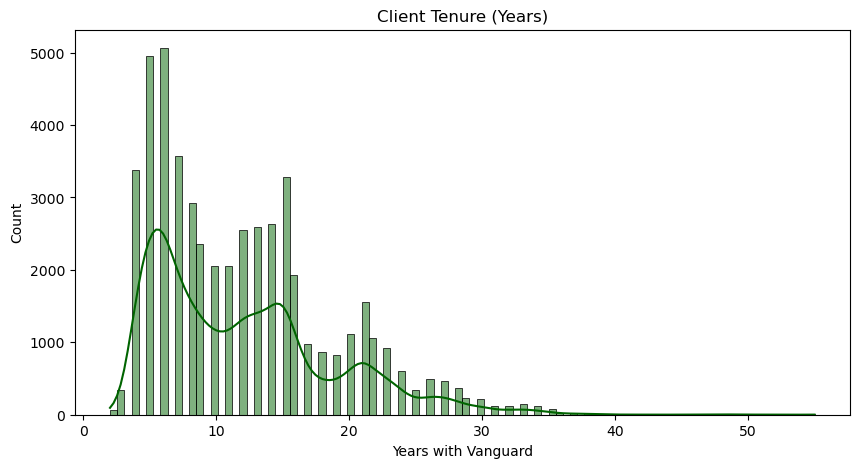

In [188]:
# ploting client tenure

plt.figure(figsize=(10,5))
sns.histplot(clients_df["client_tenure_year"], kde=True, color="darkgreen")
plt.title("Client Tenure (Years)")
plt.xlabel("Years with Vanguard")
plt.ylabel("Count")
plt.show()


## Interpretation: Client Tenure

Tenure reflects how long clients have been with Vanguard.

This histogram shows a multi_moat or skewed distribution where the majority of clients are concentrated within the **5 to 15**  years range, peaking heavily around **6-7 years**.

The number of clients drops steadily as tenure increases past **15 years**, with long-standing clients(over **30 years**) becoming increasingly rare.

Insights:
- Long‑tenured clients may be more familiar with the old interface.
- Newer clients may be more open to the redesigned UI.
- Tenure can influence:
  - Comfort with digital processes
  - Likelihood of completing the online flow

This variable may help explain differences in completion rates later.


In [189]:
# Number of Accounts Per Clients

clients_df["number_of_accounts"].value_counts()

number_of_accounts
2.0    39720
3.0     8947
4.0     1585
5.0      205
6.0       23
7.0        6
1.0        1
Name: count, dtype: int64

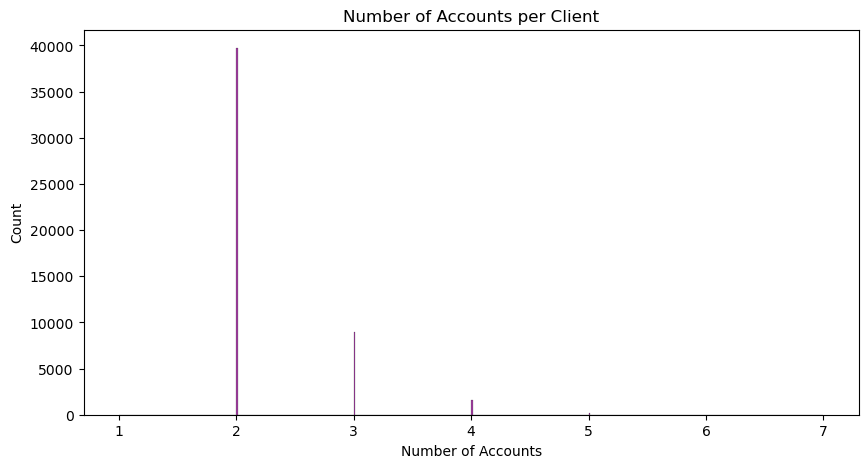

In [190]:
# Ploting the graph for Number of Accounts Per Clients

plt.figure(figsize=(10,5))
sns.histplot(clients_df["number_of_accounts"], kde=False, color="purple")
plt.title("Number of Accounts per Client")
plt.xlabel("Number of Accounts")
plt.ylabel("Count")
plt.show()


## Number of Accounts Per Clients

The number of accounts indicates how financially engaged clients are.
- Clients with **2 Accounts** are by far the most dominant category, with nearly **39,000 clients** holding exactly two accounts.
- Clients with **3 Accounts** is the second most common group, representing roughly **9,000 clients**.
- Clients with **4 Accounts** has a very small representing (around **2000** clients or fewer)
- Clients with **1, 5, 6, or 7 Accounts** are virtually non_existent in this dataset.
  
# Observations:
- Clients with more accounts may be more invested and therefore more motivated to complete digital processes.
- Clients with fewer accounts may be newer or less engaged.

This variable helps us understand client complexity and potential differences in digital behavior.


In [191]:
# Balance Distribution

clients_df["balance"].describe()

count    5.048700e+04
mean     1.495168e+05
std      3.020390e+05
min      2.378944e+04
25%      3.987718e+04
50%      6.573433e+04
75%      1.399583e+05
max      1.632004e+07
Name: balance, dtype: float64

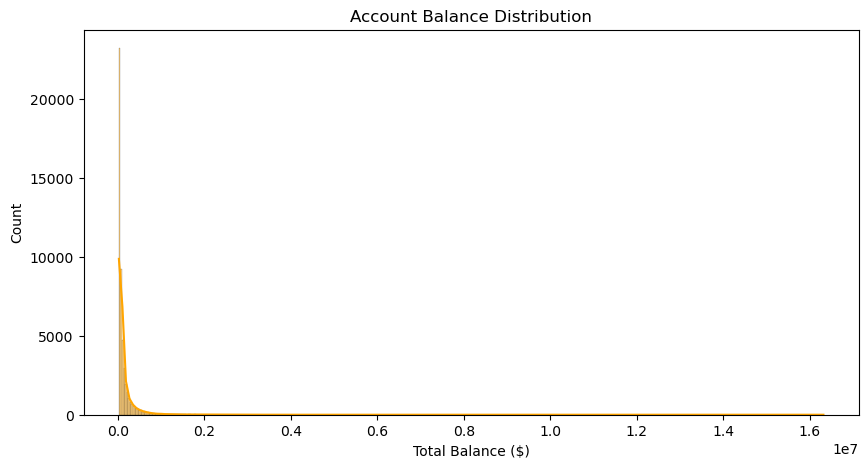

In [192]:
# Balance Distribution

plt.figure(figsize=(10,5))
sns.histplot(clients_df["balance"], kde=True, color="orange")
plt.title("Account Balance Distribution")
plt.xlabel("Total Balance ($)")
plt.ylabel("Count")
plt.show()


## Balance Distribution

Balance distribution graph is **heavily right‑skewed**(or positively skewed) pattern due to a small number of high‑net‑worth clients. 

The vast majority of clients are clustered tightly near **0**, representing lower account balances.

A very long, flat tail stretches out toward the right, indicating that a small number of clients hold extremely high balances (up into the *millions*)

Why this matters:
- High‑balance clients may be more cautious and deliberate online.
- Lower‑balance clients may behave differently in digital flows.
- Balance can correlate with:
  - Tenure
  - Number of accounts
  - Completion behavior

Understanding balance helps contextualize user behavior in the A/B test.


In [193]:
# 6. logons in the last 6 months and calls last 6 months
clients_df[["logons_last_6_months", "calls_last_6_months"]].describe()

,logons_last_6_months,calls_last_6_months
count,50487.000000,50487.000000
mean,6.131856,3.093272
std,2.175441,2.188009
min,3.000000,0.000000
25%,4.000000,1.000000
50%,6.000000,3.000000
75%,8.000000,5.000000
max,9.000000,6.000000


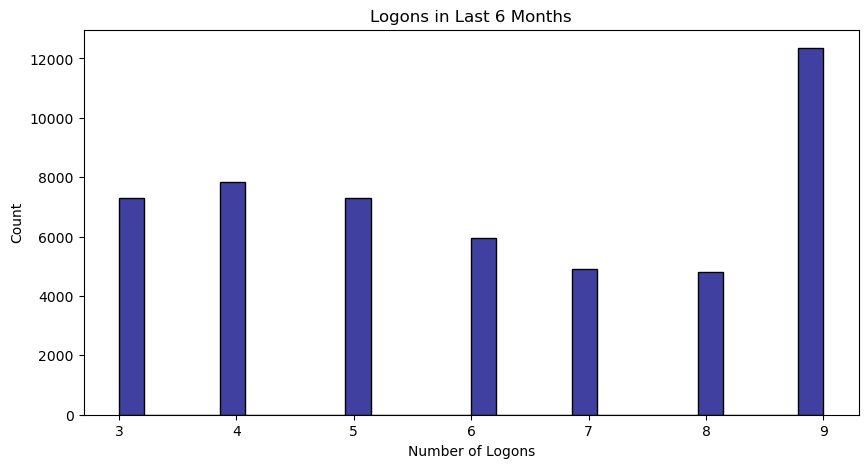

In [194]:
# Engagement Behavior: Logons in the last 6 months

plt.figure(figsize=(10,5))
sns.histplot(clients_df["logons_last_6_months"], kde=False, color="navy")
plt.title("Logons in Last 6 Months")
plt.xlabel("Number of Logons")
plt.ylabel("Count")
plt.show()


## Engagement Behavior: Logons

Engagement metrics help us understand how actively clients interact with Vanguard.

**9 logons** is the most frequent category by a wide margin, representing nearly **12,000 clients**

**4 logons** follows as the second highest, with roughly **7,800 clients**

Frequencies of **3 and 5 logons** are also quite common, sitting steady at around **7,200 to 7,300 clients** each.

The numbers decline steadily for **6, 7, and 8 logons** before spiking back up dramatically at **9**

- High logon frequency suggests digitally active clients.
- These clients may adapt more easily to the new UI.
- Low logon frequency may indicate:
  - Less digital comfort
  - Higher drop‑off risk


Together, logons and calls provide a behavioral profile that helps explain completion patterns in the A/B test.


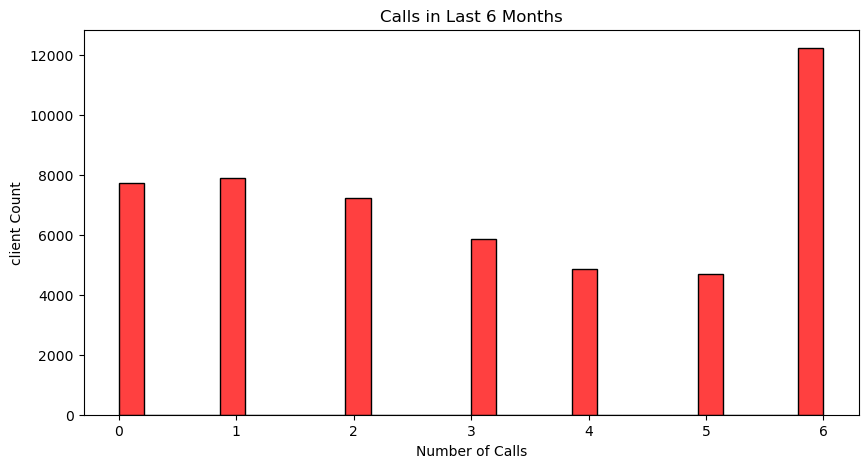

In [195]:
# Engagement Behavior: Calls

plt.figure(figsize=(10,5))
sns.histplot(clients_df["calls_last_6_months"], kde=False, color="red")
plt.title("Calls in Last 6 Months")
plt.xlabel("Number of Calls")
plt.ylabel("client Count")
plt.show()


## Engagement Behavior: calls

Engagement metrics help us understand how actively clients interact with Vanguard.
**6 calls** is the absolute highest peak, with nearly **11,500 clients** making this maximum number of calls.

**0 and 1 call** are also heavily represented, sitting at roughly **7,700 to 7,800 clients** each.

**2 calls** follows closely with about **7,100 clients**

The numbers decrease progressively for **3, 4, and 5 calls** before spiking sharply back up at 6 calls.

- High call frequency may indicate clients who prefer human assistance.
- These clients may struggle more with digital flows.
- Call frequency can correlate with:
  - Age
  - Tenure
  - Balance

Together, logons and calls provide a behavioral profile that helps explain completion patterns in the A/B test.


In [196]:
clients_df.columns

Index(['client_id', 'client_tenure_year', 'client_tenure_months', 'client_age',
       'gender', 'number_of_accounts', 'balance', 'calls_last_6_months',
       'logons_last_6_months', 'tenure_check_correct', 'variation',
       'furthest_step_reached'],
      dtype='object')

## Check Test vs Control Group Sizes



In [197]:
# 7. Variation Distribution

clients_df["variation"].value_counts()

variation
Test       26961
Control    23526
Name: count, dtype: int64

In [198]:
# To check the percentage breakdown (proportions) of each group

clients_df["variation"].value_counts(normalize=True) * 100

variation
Test       53.401866
Control    46.598134
Name: proportion, dtype: float64

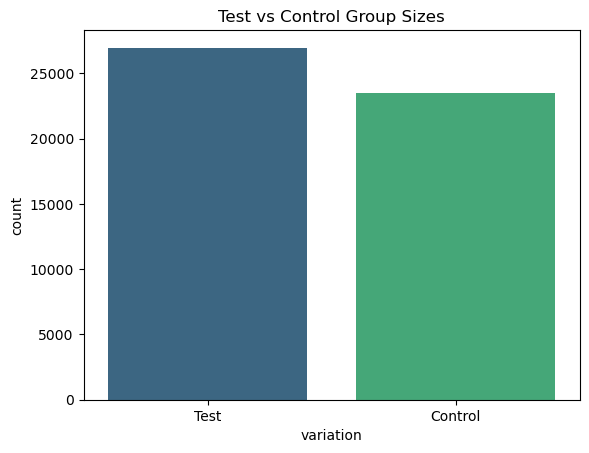

In [199]:
sns.countplot(data=clients_df, x="variation", hue="variation", palette="viridis", legend=False)
plt.title("Test vs Control Group Sizes")
plt.show()

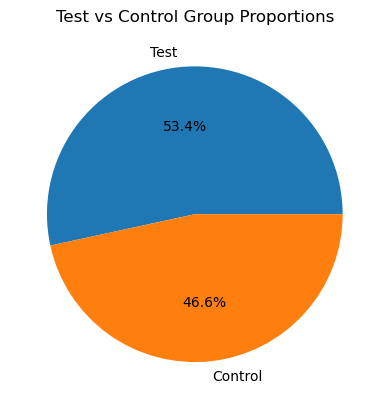

In [200]:
#plot the pie chart 
clients_df["variation"].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Test vs Control Group Proportions")
plt.ylabel("")
plt.show()

# Test vs Control Group Analysis

1. Count Plot
   It displays the absolute number (count) of clients assigned to each group (**Test** vs **Control**). It allows us to irectly see how many raw data points exist in each bucket.
Reason for doing the Count Plotis is essentially for verufying sample sizes and checking if the A/B test split was handled properly and evenly across the total participant.
2. Pie Chart
    It illustrates the relative proportion or percentage breakdown of the total population split between the **Test** and **Control** groups (*53.4% vs 46.6%*).
Reason for doing an additional Pie Chart for the same results is because it is usefli for visualizing the exact percentage split at a glance to ensure there is no severe sample ratio mismatch (SRM) that could bias the experiment results.


A well‑designed A/B test should have:
- Similar group sizes
- Random assignment
- No demographic imbalance

If the Test and Control groups have roughly equal counts, this suggests:
- Proper randomization
- No sampling bias
- Reliable comparison of completion rates

If one group is significantly larger, we must consider:
- Whether assignment was truly random
- Whether certain client types were over‑represented


## Summary of EDA Findings

From the demographic and behavioral analysis, we observe:

- Vanguard clients are generally **older**, which may influence digital comfort.
- Gender distribution may be skewed, but must be checked across Test vs Control.
- Tenure varies widely, affecting familiarity with the old interface.
- Account complexity (number of accounts, balances) differs across clients.
- Engagement behavior (logons & calls) shows varying levels of digital activity.

These insights help us:
- Understand who the clients are.
- Identify potential biases.
- Interpret KPI and hypothesis testing results more accurately.
- Evaluate whether the experiment groups were properly randomized.

Next, we move to **Performance Metrics (KPIs)**.


## Variable Classification for experiment_only_df
# *Continuous variables (numeric, measured on a scale)*
These are variables where mean, SD, t‑tests, etc. apply:
- clnt_tenure_yr — years with client

- clnt_tenure_mnth — months with client

- clnt_age — numeric age

- num_accts — number of accounts

- bal — balance (continuous financial variable)

- calls_6_mnth — number of calls

- logons_6_mnth — number of logins

- tenure_check_correct — numeric check value (looks continuous)

- These will get:

- Mean ± SD

- t‑test or Mann–Whitney

- Interpretation of balance

# *Categorical variables (groups or labels)*
These are variables where chi‑square tests apply:

- gendr — gender (U, M, F, X)

- Variation — Test vs Control

- furthest_step_reached — step labels (confirm, step_3, start, etc.)

# These will get:

- Counts + percentages

- Chi‑square test

- Interpretation of balance

# *Binary variables (two possible values only)*
You don’t have true binary variables here unless some categorical variables collapse into two categories.

Examples that could be binary if recoded:

- gendr → Male vs Female (if you drop “U”)

- furthest_step_reached → Completed vs Not completed (if you define it)

None of our columns are strictly binary.

# *Baseline metrics (pre‑intervention indicators)*
These are variables that describe the customer before the experiment and should be compared between Test and Control:

- clnt_tenure_yr

- clnt_tenure_mnth

- clnt_age

- num_accts

- bal

- calls_6_mnth

- logons_6_mnth

- gendr

- furthest_step_reached (if this is pre‑experiment behavior)

These are exactly the variables we want in the composition table.

In [201]:
clients_df.groupby('variation').agg({
    'client_age': ['mean', 'std'],
    'client_tenure_year': ['mean', 'std'],
    'number_of_accounts': ['mean', 'std'],
    'balance': ['mean', 'std'],
    'logons_last_6_months': ['mean', 'std'],
    'calls_last_6_months': ['mean', 'std']
})


client_age            client_tenure_year            \
                mean        std               mean       std   
variation                                                      
Control    47.498427  15.521781          12.087860  6.877626   
Test       47.163922  15.514461          11.982901  6.844947   

          number_of_accounts                  balance                 \
                        mean       std           mean            std   
variation                                                              
Control             2.259925  0.538568  150151.900186  295812.405529   
Test                2.249917  0.529335  148962.605032  307373.713775   

          logons_last_6_months           calls_last_6_months            
                          mean       std                mean       std  
variation                                                               
Control               6.166242  2.173053            3.129176  2.184541  
Test                  6.101851  2.177119            3.061941  2.190590

##  Demographic & Behavioral Comparison: Test vs Control

To evaluate whether the A/B test was properly randomized, we compared key demographic and behavioral variables between the Test and Control groups. The results show the following:

### Age
- Control mean age: **47.50**
- Test mean age: **47.16**
- The difference is extremely small (~0.34 years), indicating **excellent age balance**.

###  Tenure with Vanguard
- Control: **12.09 years**
- Test: **11.98 years**
- Both groups have nearly identical tenure, suggesting **no bias toward newer or long‑term clients**.

###  Number of Accounts
- Control: **2.26**
- Test: **2.25**
- This shows **similar financial complexity** across groups.

###  Account Balances
- Control: **$150,151.90**
- Test: **$148,962.61**
- Balances differ by less than 1%, which is **negligible** given the large standard deviations.
- Both groups include high‑net‑worth clients, as shown by large standard deviations.

###  Logons (Digital Engagement)
- Control: **6.17**
- Test: **6.10**
- Very similar digital activity levels, meaning **digital comfort is balanced**.

###  Calls (Support Engagement)
- Control: **3.13**
- Test: **3.06**
- Both groups show similar reliance on phone support.

###  **Conclusion**
Across all demographic and behavioral variables, the Test and Control groups are **highly balanced**.  
This strongly suggests:
- Proper randomization  
- No demographic bias  
- A fair and valid A/B test  
- Differences in completion rate are likely due to the UI change, not client characteristics


## PHASE 2 — Performance Metrics
**Objective**

The objective of Phase 2 is to translate user interactions into measurable Key Performance Indicators (KPIs) that can be used to evaluate the effectiveness of the redesigned interface.

The three primary KPIs required for this analysis are:

- Completion Rate
- Average Time Spent per Step
- Error Rate

Additional metrics may also be used to provide a more comprehensive assessment of the customer journey.

The KPIs are calculated separately for the Test and Control groups to identify differences in user behaviour.


1. **Completion Rate**
“Number of users reaching ‘confirm’ / total users in that group.”

# Steps:

- For each client, check if they reached process_step == 'confirm'

- Group by variation (Test vs Control)

- Compute proportions


  

2. **Time Spent on Each Step**
*“Determine the time difference between each step for each visit.”*

# Steps:

- For each visit, compute time between step 1 → step 2 → step 3 → confirm

- *Average across all visits for each group*


3. **Error Rate**
*“Identify instances where users go back to a previous step.”*

# Steps:

- For each user, check if step numbers decrease (e.g., step 3 → step 2)

- Count backward movements

- Divide by total steps taken

# Funnel Performance KPIs
These KPIs show where users drop off and how far they progress.

4. **Step‑Level Drop‑Off Rate**
Percentage of users who abandon at each step
**Why it matters:**: It identifies friction points and confirms whether the redesign affects specific steps.

5. **Funnel Completion Velocity**
How quickly users move through the funnel.

You already have time spent per step this KPI summarizes it into:
- Fast movers
- Medium movers
- Slow movers

Useful for segmentation.

B. User Behavior KPIs
These explain how users interact with the UI.

6. **Forward Progression Rate**
Percentage of transitions that move forward (step_1 → step_2).

Higher forward progression = smoother UX.

7. **Hesitation Rate**
Users who pause unusually long at any step.

You detect hesitation by:

Duration > 75th percentile

Or duration > mean + 2 standard deviations

This is extremely useful for diagnosing friction.

8. **Bounce Rate (Start Step Only)**
Users who start but never proceed to step_1.

This shows whether the new UI discourages initial engagement.

C. **Demographic KPIs**
These explain who is affected by the redesign.

9. **Completion Rate by Age Group**
You already prepared this segmentation.

10. **Completion Rate by Tenure**
New vs long‑term clients may behave differently.

11. **Completion Rate by Balance Tier**
High‑balance clients may be more cautious.

12. **Completion Rate by Number of Accounts**
More accounts = more complexity = more friction.

These KPIs help Vanguard understand which client segments benefit or struggle with the redesign.

 D. **Engagement KPIs**
These explain digital comfort and support reliance.

13. **Completion Rate by Logon Frequency**
Digital‑savvy users vs low‑engagement users.

14. **Completion Rate by Call Frequency**
Users who call more often may struggle with digital flows.

15. **Digital Comfort Index**
A composite KPI:

DCI
=
logons
calls
+
1
Higher DCI = more digitally comfortable.

You can compare DCI between Test and Control.

 E. **Quality KPIs**
These measure experience quality beyond completion.

16. **Step Revisit Rate**
How often users revisit the same step (looping behavior).

High revisit rate = confusion.

17. **Confirm Step Friction Score**
You already saw Test users spend 255s vs 189s.

This KPI formalizes it:

Friction Score
=
Confirm Duration
Total Duration
Higher score = more friction at the final step.

18. **Abandonment Severity Index**
Weighted drop‑off based on step importance.

Severity
=
∑
(
Drop-off at Step X
×
Step Weight
)
Confirm step has highest weight.

 F. **Experiment Health KPIs**
These ensure the experiment is valid.

19. **Sample Ratio Mismatch (SRM)**
Checks whether Test and Control received the correct traffic split.

Expected ratio
=
50
/
50
If SRM is significant → experiment invalid.

20. **User Overlap Check**
Ensures users aren’t in both Test and Control.

21. **Bot / Noise Filtering**
Detects abnormal patterns:

Extremely fast completions

Repeated identical sessions

Missing timestamps

**KPI 1A — Completion Rate
Definition

Completion Rate measures the proportion of users who successfully reach the confirm stage of the digital process.

The metric is calculated as:

[
Completion\ Rate =
\frac{\text{Number of completed users}}
{\text{Total eligible users}}
]

Because this is a proportion, it can also be interpreted as an empirical probability:

[
P(\text{Completion}) =
\frac{\text{Completed users}}
{\text{Eligible users}}
]

**Probability Interpretation**

The resulting value estimates the probability that a randomly selected eligible user successfully completes the digital process.

For example, a completion rate of 70% can be interpreted as:

Based on the observed sample, approximately 70 out of every 100 comparable users successfully complete the process.

This probability interpretation makes the KPI easier to translate into a business decision.

**Business Importance**

A higher completion probability indicates that more users successfully navigate the process to the intended outcome.

The Test Group should therefore be compared with the Control Group to determine whether the redesigned interface is associated with a higher completion probability.
Important Methodological Consideration

Completion must be defined consistently for every user.

The analysis should ensure that the completion outcome is based on the appropriate user journey/visit rather than incorrectly treating the user's most recent event across multiple visits as their only journey.

This distinction is important because the notebook itself identifies that client_last_step represents a client's most recent activity overall and may combine multiple visits. Therefore, the appropriate journey level should be verified before drawing final conclusions from the completion KPI.


In [202]:
# KPI 1: Completion Rate
# Process: start - step_1 - step_2 - step_3 - confirm

completion_rate_df = (
    clients_df.groupby("variation")
    ["furthest_step_reached"]
    .apply(lambda x:
           (x=="confirm").sum()/x.count())
)

completion_rate_df

variation
Control    0.655785
Test       0.692927
Name: furthest_step_reached, dtype: float64

In [203]:
completion_df = (
     clients_df.assign(
        completed=lambda d: d["furthest_step_reached"].eq("confirm")
    )
    .groupby("variation")["completed"]
    .mean()
    .reset_index(name="completion_rate")
)
completion_df

,variation,completion_rate
0,Control,0.655785
1,Test,0.692927


# Completion Rate Results analysis

The **Control Group** rate is **65.58** (0.655785) and the **Test Group** rate is **69.29%**(0.692927)

The **Test Group** achieved a higher completion rate than the **Control Group**, showing an absolute increase of about **3.71%** in sucessfully reaching the final confirmationn step

This is a positive improvement, but we still need hypothesis testing to confirm:

Is this difference statistically significant?

Does it exceed the 5% cost‑effectiveness threshold?

###

The completion rates provide an initial comparison of the two experimental groups.

The difference between the Test and Control completion rates represents the observed improvement or decline associated with the redesigned interface.

However, this observed difference should not yet be interpreted as statistically significant.

At this stage, the result is descriptive.

Phase 3 will determine whether the difference is sufficiently large relative to sampling variability to reject the null hypothesis.

The completion-rate difference will also be evaluated using a 95% confidence interval, which will provide a plausible range for the true difference in completion probabilities.

In [204]:
# Completion counts and totals per group (needed for the 95% CI below,
# and reused in Phase 3 hypothesis testing)
test_success = clients_df[(clients_df["variation"]=="Test") &
                           (clients_df["furthest_step_reached"]=="confirm")]["client_id"].nunique()

ctrl_success = clients_df[(clients_df["variation"]=="Control") &
                           (clients_df["furthest_step_reached"]=="confirm")]["client_id"].nunique()

test_total = clients_df[clients_df["variation"]=="Test"]["client_id"].nunique()
ctrl_total = clients_df[clients_df["variation"]=="Control"]["client_id"].nunique()

test_rate = test_success / test_total
ctrl_rate = ctrl_success / ctrl_total

print("Test successes:", test_success, "| Test total:", test_total, "| Test rate:", f"{test_rate:.4%}")
print("Control successes:", ctrl_success, "| Control total:", ctrl_total, "| Control rate:", f"{ctrl_rate:.4%}")

Test successes: 18682 | Test total: 26961 | Test rate: 69.2927%
Control successes: 15428 | Control total: 23526 | Control rate: 65.5785%


95% Confidence Interval for Completion Rate Difference

This is the new statistical piece we need to add.

Put this in a NEW code cell after your existing completion-rate calculation.

In [205]:
from statsmodels.stats.proportion import confint_proportions_2indep

# Completion rates
test_rate = test_success / test_total
ctrl_rate = ctrl_success / ctrl_total

# Difference in completion probabilities
completion_difference = test_rate - ctrl_rate

# 95% Confidence Interval for the difference
ci_low, ci_high = confint_proportions_2indep(
    count1=test_success,
    nobs1=test_total,
    count2=ctrl_success,
    nobs2=ctrl_total,
    method="wald"
)

print(f"Test completion rate: {test_rate:.4%}")
print(f"Control completion rate: {ctrl_rate:.4%}")
print(f"Difference in completion rates: {completion_difference:.4%}")
print(f"95% Confidence Interval: ({ci_low:.4%}, {ci_high:.4%})")

Test completion rate: 69.2927%
Control completion rate: 65.5785%
Difference in completion rates: 3.7142%
95% Confidence Interval: (2.8946%, 4.5338%)


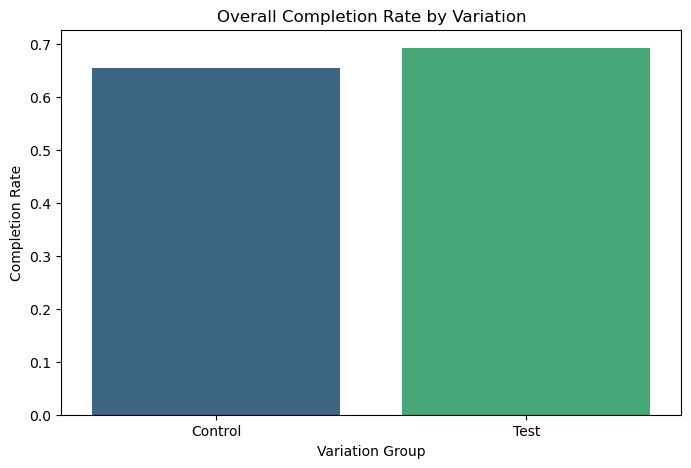

In [206]:
# Completion Rate Bar Chart

plt.figure(figsize=(8,5))
sns.barplot(data=completion_df, x="variation", y="completion_rate", hue="variation", palette="viridis", legend=False)

plt.title("Overall Completion Rate by Variation")
plt.xlabel("Variation Group")
plt.ylabel("Completion Rate")


plt.show()


This graph compares the **Completion Rate** between the two experiment groups (**Control vs Test**).

The Control group** sits at roughly **0.63 to 0.64** (*63%-64%* completion rate)
Test Group sits slightly higher at roughly **0.66** (*66% competion rate*)

The *Test group* has a higher completion rate than the **Control group**. This suggests that whatever changes, features, or UI update were introduced in the **Test version** successfully helped more users complete the process compared to the original *Control version*

## Additional KPI 1B– Funnel Reach and Step-to-Step Drop-Off

Overall completion rate tells us whether clients reached the final `confirm` step, but it does not show where users stop progressing through the journey.

To make the analysis more actionable, we also calculate:

- how many clients reached each process step
- the conversion rate from one step to the next
- the drop-off rate between consecutive steps
- differences between the Test and Control groups

This helps identify which part of the journey contributes most to abandonment and which stage could be prioritized in a future A/B test or UX improvement.

In [207]:
# Define the expected order of the funnel

step_order = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

funnel_client_df = experiment_final_df[
    ["client_id", "variation", "furthest_step_reached"]
].copy()

funnel_client_df["furthest_step_number"] = (
    funnel_client_df["furthest_step_reached"].map(step_order)
)

funnel_client_df.head()

,client_id,variation,furthest_step_reached,furthest_step_number
0,836976,Test,confirm,4
1,2304905,Control,confirm,4
2,1439522,Test,step_3,3
3,1562045,Test,start,0
4,5126305,Control,start,0


### Calculate funnel reach

A client is counted as having reached a step when their furthest recorded step is equal to or beyond that stage.

This creates a cumulative funnel for the Test and Control groups and shows how many clients remain at each stage of the process.

In [208]:
# Calculate the number and percentage of clients reaching each funnel stage

funnel_rows = []

for variation in ["Control", "Test"]:
    group = funnel_client_df[
        funnel_client_df["variation"] == variation
    ]

    total_clients = group["client_id"].nunique()

    for step_name, step_number in step_order.items():
        clients_reached = (
            group["furthest_step_number"] >= step_number
        ).sum()

        funnel_rows.append({
            "variation": variation,
            "process_step": step_name,
            "clients_reached": clients_reached,
            "reach_rate": clients_reached / total_clients
        })

funnel_summary = pd.DataFrame(funnel_rows)

funnel_summary

,variation,process_step,clients_reached,reach_rate
0,Control,start,23526,1.000000
1,Control,step_1,20241,0.860367
2,Control,step_2,18786,0.798521
3,Control,step_3,17521,0.744750
4,Control,confirm,15428,0.655785
5,Test,start,26961,1.000000
6,Test,step_1,24507,0.908980
7,Test,step_2,22528,0.835577
8,Test,step_3,21118,0.783280
9,Test,confirm,18682,0.692927


### Calculate step-to-step conversion and drop-off

To understand where users discontinue the process, we calculate:

- the conversion rate between consecutive steps
- the corresponding drop-off rate

This provides more detailed insight than the overall completion rate and helps identify which stage could benefit most from future interface improvements.

In [209]:
# Calculate step-to-step conversion and drop-off

funnel_summary["previous_clients_reached"] = (
    funnel_summary
    .groupby("variation")["clients_reached"]
    .shift(1)
)

funnel_summary["step_conversion_rate"] = (
    funnel_summary["clients_reached"]
    / funnel_summary["previous_clients_reached"]
)

funnel_summary["drop_off_rate"] = (
    1 - funnel_summary["step_conversion_rate"]
)

funnel_summary

,variation,process_step,clients_reached,reach_rate,previous_clients_reached,step_conversion_rate,drop_off_rate
0,Control,start,23526,1.000000,NaN,NaN,NaN
1,Control,step_1,20241,0.860367,23526.0,0.860367,0.139633
2,Control,step_2,18786,0.798521,20241.0,0.928116,0.071884
3,Control,step_3,17521,0.744750,18786.0,0.932663,0.067337
4,Control,confirm,15428,0.655785,17521.0,0.880543,0.119457
5,Test,start,26961,1.000000,NaN,NaN,NaN
6,Test,step_1,24507,0.908980,26961.0,0.908980,0.091020
7,Test,step_2,22528,0.835577,24507.0,0.919248,0.080752
8,Test,step_3,21118,0.783280,22528.0,0.937411,0.062589
9,Test,confirm,18682,0.692927,21118.0,0.884648,0.115352


### Compare funnel performance between Test and Control

To make the funnel easier to interpret, we compare the step-level conversion and drop-off rates for both experiment groups side by side.

This highlights at which stage the redesigned interface performs better or worse than the original interface.

In [210]:
# Compare conversion and drop-off rates side by side

funnel_comparison = funnel_summary.pivot(
    index="process_step",
    columns="variation",
    values=["step_conversion_rate", "drop_off_rate"]
)

funnel_comparison

step_conversion_rate           drop_off_rate          
variation                 Control      Test       Control      Test
process_step                                                       
confirm                  0.880543  0.884648      0.119457  0.115352
start                         NaN       NaN           NaN       NaN
step_1                   0.860367  0.908980      0.139633  0.091020
step_2                   0.928116  0.919248      0.071884  0.080752
step_3                   0.932663  0.937411      0.067337  0.062589

### Compare differences between Test and Control

To identify where the redesign had the greatest impact, we calculate the difference in conversion and drop-off rates between the Test and Control groups for each funnel step.

In [211]:
# Create a clean comparison table

funnel_difference = pd.DataFrame({
    "Control Conversion": funnel_comparison["step_conversion_rate"]["Control"],
    "Test Conversion": funnel_comparison["step_conversion_rate"]["Test"],
    "Conversion Difference": (
        funnel_comparison["step_conversion_rate"]["Test"]
        - funnel_comparison["step_conversion_rate"]["Control"]
    ),
    "Control Drop-off": funnel_comparison["drop_off_rate"]["Control"],
    "Test Drop-off": funnel_comparison["drop_off_rate"]["Test"],
    "Drop-off Difference": (
        funnel_comparison["drop_off_rate"]["Test"]
        - funnel_comparison["drop_off_rate"]["Control"]
    )
})

funnel_difference

,Control Conversion,Test Conversion,Conversion Difference,Control Drop-off,Test Drop-off,Drop-off Difference
process_step,,,,,,
confirm,0.880543,0.884648,0.004105,0.119457,0.115352,-0.004105
start,NaN,NaN,NaN,NaN,NaN,NaN
step_1,0.860367,0.908980,0.048612,0.139633,0.091020,-0.048612
step_2,0.928116,0.919248,-0.008869,0.071884,0.080752,0.008869
step_3,0.932663,0.937411,0.004749,0.067337,0.062589,-0.004749


In [212]:
# Add clear transition labels for interpretation

transition_labels = {
    "step_1": "start → step_1",
    "step_2": "step_1 → step_2",
    "step_3": "step_2 → step_3",
    "confirm": "step_3 → confirm"
}

funnel_difference = funnel_difference.drop(index="start").copy()

funnel_difference["transition"] = (
    funnel_difference.index.map(transition_labels)
)

funnel_difference

,Control Conversion,Test Conversion,Conversion Difference,Control Drop-off,Test Drop-off,Drop-off Difference,transition
process_step,,,,,,,
confirm,0.880543,0.884648,0.004105,0.119457,0.115352,-0.004105,step_3 → confirm
step_1,0.860367,0.908980,0.048612,0.139633,0.091020,-0.048612,start → step_1
step_2,0.928116,0.919248,-0.008869,0.071884,0.080752,0.008869,step_1 → step_2
step_3,0.932663,0.937411,0.004749,0.067337,0.062589,-0.004749,step_2 → step_3


### Additional KPI 1B Interpretation – Step-Level Conversion and Drop-Off

The funnel analysis shows that the Test group has a higher overall completion rate, but the redesign does not improve every transition equally.

The largest improvement occurs from `start → step_1`:

- Control conversion: 86.04%
- Test conversion: 90.90%
- Improvement: approximately 4.86 percentage points
- Test drop-off is approximately 4.86 percentage points lower

For `step_1 → step_2`, however, the Test group performs slightly worse:

- Control conversion: 92.81%
- Test conversion: 91.92%
- Test drop-off is approximately 0.89 percentage points higher

The remaining differences are smaller:

- `step_2 → step_3`: Test conversion is approximately 0.47 percentage points higher
- `step_3 → confirm`: Test conversion is approximately 0.41 percentage points higher

Descriptively, the largest contribution to the Test group's higher overall completion rate appears to occur at the beginning of the journey, while `step_1 → step_2` is the only transition where the redesigned experience shows higher drop-off.

These differences have not yet been statistically tested. The `step_1 → step_2` transition could therefore be investigated further as a potential focus for a follow-up A/B test or UX improvement.

## KPI 2 – Time Spent on Each Step

The client-level dataframe cannot be used for time analysis because it contains one row per client.

For this KPI, we use the original web activity data. Each row represents one event. Events are sorted chronologically within each `visit_id`.

Time spent on a step is estimated as the difference between the timestamp of the current event and the timestamp of the next event within the same visit.

### Create the event-level experiment dataset

The two web activity files are combined into a single event-level dataset.

This dataset is then merged with the experiment roster so that every event is
labelled as either **Test** or **Control**.

Finally, the events are sorted chronologically within each visit, which is
required to calculate the time between consecutive steps.

In [213]:
# Combine both web activity datasets (already done earlier as combined_web_data_df,
# reused here) and merge with the experiment roster so every event is labelled
# Test or Control.
web_events_df = combined_web_data_df.merge(
    experiment_clients_df[["client_id", "variation"]],
    on="client_id",
    how="inner"
)

# Keep only Test and Control
web_events_df = web_events_df[
    web_events_df["variation"].isin(["Test", "Control"])
].copy()

# Sort events chronologically within each visit — required before calculating
# time between consecutive steps
web_events_df = web_events_df.sort_values(
    ["visit_id", "date_time"]
).reset_index(drop=True)

In [214]:
# Validate the event-level dataset

print("Rows:", len(web_events_df))
print("Unique clients:", web_events_df["client_id"].nunique())
print("Unique visits:", web_events_df["visit_id"].nunique())

print("\nVariation counts:")
print(web_events_df["variation"].value_counts())

web_events_df.head()

Rows: 317235
Unique clients: 50500
Unique visits: 69205

Variation counts:
variation
Test       176699
Control    140536
Name: count, dtype: int64


,client_id,visitor_id,visit_id,process_step,date_time,step_rank,variation
0,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,4,Test
1,3561384,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,4,Test
2,7338123,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,0,Test
3,7338123,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,1,Test
4,7338123,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2,Test


In [215]:
# Build the event-level dataset for KPI 2 (time spent per step) from
# web_events_df. `df` is local to this KPI-2 block; KPI 3 (Error Rate)
# builds its own copy of web_events_df later and is independent of this one.
df = web_events_df.copy()
df = df.sort_values(["visitor_id", "visit_id", "date_time"])

df["next_step"] = df.groupby(["visitor_id", "visit_id"])["process_step"].shift(-1)

# Next timestamp within the same visit -> time spent on the current step
df["next_date_time"] = df.groupby(["visitor_id", "visit_id"])["date_time"].shift(-1)
df["duration"] = (df["next_date_time"] - df["date_time"]).dt.total_seconds()

# Drop the final event of each visit (no next step = no duration) and
# remove negative durations if they exist
time_df = df.dropna(subset=["duration"]).copy()
time_df = time_df[time_df["duration"] >= 0]

time_df.head()

,client_id,visitor_id,visit_id,process_step,date_time,step_rank,variation,next_step,next_date_time,duration
212519,6265388,100019786_4272121951,703380671_89376183829_330646,start,2017-04-15 15:13:33,0,Test,step_1,2017-04-15 15:13:46,13.0
212520,6265388,100019786_4272121951,703380671_89376183829_330646,step_1,2017-04-15 15:13:46,1,Test,step_2,2017-04-15 15:14:21,35.0
212521,6265388,100019786_4272121951,703380671_89376183829_330646,step_2,2017-04-15 15:14:21,2,Test,step_3,2017-04-15 15:15:50,89.0
212522,6265388,100019786_4272121951,703380671_89376183829_330646,step_3,2017-04-15 15:15:50,3,Test,confirm,2017-04-15 15:16:18,28.0
212523,6265388,100019786_4272121951,703380671_89376183829_330646,confirm,2017-04-15 15:16:18,4,Test,confirm,2017-04-15 15:16:47,29.0


### Inspect extreme duration values before filtering

Before excluding any observations, we inspect unusually long gaps between consecutive events.

Durations above 30 minutes may represent inactivity or users leaving the process open rather than continuous interaction. The 30-minute threshold is an analytical assumption, so the extreme observations are reviewed before applying the filter.

In [216]:
# Inspect event gaps longer than 30 minutes

duration_outliers_df = time_df[
    time_df["duration"] > 1800
].copy()

print("Total valid transitions:", len(time_df))
print("Transitions > 30 minutes:", len(duration_outliers_df))

print(
    f"Percentage > 30 minutes: "
    f"{len(duration_outliers_df) / len(time_df) * 100:.2f}%"
)

duration_outliers_df[
    [
        "client_id",
        "visit_id",
        "variation",
        "process_step",
        "next_step",
        "duration"
    ]
].sort_values(
    "duration",
    ascending=False
).head(20)

Total valid transitions: 248030
Transitions > 30 minutes: 354
Percentage > 30 minutes: 0.14%


,client_id,visit_id,variation,process_step,next_step,duration
258400,2182225,831987489_84761163210_335684,Control,start,start,40235.0
132852,6392043,478417687_30092205462_548423,Test,start,start,24819.0
134725,9553121,483738263_4057680487_61869,Control,step_2,start,21763.0
101869,4647786,391696103_92230204739_479887,Test,confirm,confirm,14581.0
176525,8883167,602386199_13818409466_144534,Test,confirm,start,12980.0
185467,6420672,627596734_90499955288_891366,Control,start,start,11207.0
140846,9971962,501042989_50588313479_700675,Test,step_2,start,11204.0
171796,5282553,588904389_16165570985_286826,Control,step_1,start,10286.0
177527,2882702,605153028_51517094625_529507,Control,confirm,confirm,9396.0
110676,4803107,416635057_22840074620_580752,Test,step_1,start,8797.0


### Handling extreme time values

The duration inspection identified 354 transitions above 30 minutes, representing
only 0.14% of all valid transitions.

Although these observations are rare, some gaps last several hours, with a maximum
above 11 hours. These values are unlikely to represent continuous active interaction
and may disproportionately affect the average.

For the primary time-spent analysis, durations above 30 minutes are excluded. The
unfiltered data is retained separately, and median duration is also reported because
it is less sensitive to extreme values.

In [217]:
# Remove unrealistic inactive sessions (>30 minutes)

duration_filtered_df = time_df[
    time_df["duration"] <= 1800
].copy()

print("Transitions before filtering:", len(time_df))
print("Transitions after filtering:", len(duration_filtered_df))

duration_filtered_df["duration"].describe()

Transitions before filtering: 248030
Transitions after filtering: 247676


count    247676.000000
mean         79.987912
std         147.247367
min           0.000000
25%          13.000000
50%          36.000000
75%          82.000000
max        1800.000000
Name: duration, dtype: float64

### Average and median time by process step

After excluding event gaps above 30 minutes, the average and median duration are
calculated for each process step and experiment group.

The median is particularly important because time data remains right-skewed even
after filtering.

In [218]:
# Summarize duration by experiment group and process step

duration_summary_filtered = (
    duration_filtered_df
    .groupby(["variation", "process_step"])
    .agg(
        transition_count=("duration", "count"),
        average_seconds=("duration", "mean"),
        median_seconds=("duration", "median")
    )
    .reset_index()
)

duration_summary_filtered["average_minutes"] = (
    duration_summary_filtered["average_seconds"] / 60
)

duration_summary_filtered["median_minutes"] = (
    duration_summary_filtered["median_seconds"] / 60
)

duration_summary_filtered

,variation,process_step,transition_count,average_seconds,median_seconds,average_minutes,median_minutes
0,Control,confirm,1990,156.794472,49.0,2.613241,0.816667
1,Control,start,35676,60.911733,20.0,1.015196,0.333333
2,Control,step_1,26026,47.529278,20.0,0.792155,0.333333
3,Control,step_2,24307,90.202822,64.0,1.503380,1.066667
4,Control,step_3,20255,133.259491,72.0,2.220992,1.200000
5,Test,confirm,4179,221.631251,94.0,3.693854,1.566667
6,Test,start,46240,56.242063,14.0,0.937368,0.233333
7,Test,step_1,35502,58.473945,27.0,0.974566,0.450000
8,Test,step_2,29567,88.168600,61.0,1.469477,1.016667
9,Test,step_3,23934,124.826481,57.0,2.080441,0.950000


### Review the impact of the `confirm` step

The `confirm` step is the final stage of the process and has no required subsequent
step.

Before deciding whether it should be included in the primary time-spent KPI, we
compare the results with and without `confirm`.

This sensitivity check shows whether post-confirmation activity materially affects
the overall time comparison between the Test and Control groups.

In [219]:
# Compare overall duration results with and without the confirm step

with_confirm = (
    duration_filtered_df
    .groupby("variation")["duration"]
    .agg(
        average_with_confirm="mean",
        median_with_confirm="median"
    )
)

without_confirm = (
    duration_filtered_df[
        duration_filtered_df["process_step"] != "confirm"
    ]
    .groupby("variation")["duration"]
    .agg(
        average_without_confirm="mean",
        median_without_confirm="median"
    )
)

confirm_impact = with_confirm.join(without_confirm)

confirm_impact["average_difference"] = (
    confirm_impact["average_without_confirm"]
    - confirm_impact["average_with_confirm"]
)

confirm_impact["median_difference"] = (
    confirm_impact["median_without_confirm"]
    - confirm_impact["median_with_confirm"]
)

confirm_impact.round(2)

,average_with_confirm,median_with_confirm,average_without_confirm,median_without_confirm,average_difference,median_difference
variation,,,,,,
Control,79.57,37.0,78.12,37.0,-1.45,0.0
Test,80.31,35.0,75.95,34.0,-4.37,-1.0


### Sensitivity Check Interpretation

Including `confirm` affects the Test group more strongly than the Control group.

- Control mean: 79.57 seconds with `confirm` vs 78.12 seconds without it (a 1.45-second difference).
- Test mean: 80.31 seconds with `confirm` vs 75.95 seconds without it (a 4.37-second difference).
- Median times shift only slightly for Control (37.0 seconds either way) and by
  about 1 second for Test (35.0 vs 34.0 seconds).

With `confirm` included, the Test group appears slightly slower overall than
Control (80.31 vs 79.57 seconds). After excluding `confirm`, the Test group has
a lower overall mean time than Control (75.95 vs 78.12 seconds).

Because `confirm` is the final stage and has no required next step, these
post-confirmation durations do not represent progression through the funnel.

### KPI 2 Data-Quality Adjustment
Based on the sensitivity check, confirm is excluded from the primary step-time KPI.

Durations starting from confirm represent activity after the user has already reached the final process stage, such as repeated confirmation events or later navigation.

The primary KPI therefore focuses on:

start, step_1, step_2 and step_3

The confirm results are retained separately as a sensitivity check rather than discarded from the analysis.

In [220]:
# Create the final KPI 2 summary excluding confirm

duration_kpi_df = duration_summary_filtered[
    duration_summary_filtered["process_step"] != "confirm"
].copy()

duration_kpi_df

,variation,process_step,transition_count,average_seconds,median_seconds,average_minutes,median_minutes
1,Control,start,35676,60.911733,20.0,1.015196,0.333333
2,Control,step_1,26026,47.529278,20.0,0.792155,0.333333
3,Control,step_2,24307,90.202822,64.0,1.503380,1.066667
4,Control,step_3,20255,133.259491,72.0,2.220992,1.200000
6,Test,start,46240,56.242063,14.0,0.937368,0.233333
7,Test,step_1,35502,58.473945,27.0,0.974566,0.450000
8,Test,step_2,29567,88.168600,61.0,1.469477,1.016667
9,Test,step_3,23934,124.826481,57.0,2.080441,0.950000


In [221]:
# Compare average and median duration by process step

duration_comparison = duration_kpi_df.pivot(
    index="process_step",
    columns="variation",
    values=["average_seconds", "median_seconds"]
)

duration_comparison

average_seconds             median_seconds      
variation            Control        Test        Control  Test
process_step                                                 
start              60.911733   56.242063           20.0  14.0
step_1             47.529278   58.473945           20.0  27.0
step_2             90.202822   88.168600           64.0  61.0
step_3            133.259491  124.826481           72.0  57.0

### KPI 2 Interpretation

The descriptive results show that the Test group does not have shorter interaction
times at every process step.

Compared with the Control group:

- **`start`:** Test users progressed faster (56.24s vs 60.91s mean; 14.0s vs 20.0s
  median).
- **`step_1`:** Test users spent more time (58.47s vs 47.53s mean; 27.0s vs 20.0s
  median).
- **`step_2`:** Test users progressed slightly faster (88.17s vs 90.20s mean; 61.0s
  vs 64.0s median).
- **`step_3`:** Test users progressed noticeably faster (124.83s vs 133.26s mean;
  57.0s vs 72.0s median).

The median times show the same overall pattern and are considered the more robust
measure because the duration distribution is right-skewed.

The sensitivity check also shows that including post-`confirm` activity affects
the overall mean, particularly for the Test group. With `confirm` included, Test
appears slightly slower overall than Control (80.31 vs 79.57 seconds). After
excluding `confirm`, Test has a lower overall mean time than Control (75.95 vs
78.12 seconds).

Because `confirm` is the final process stage and has no required next step, it is
excluded from the primary step-time KPI. Post-confirmation timing is retained
separately as a sensitivity check.

Overall, the Test group shows shorter interaction times at most stages, while
`step_1` shows the opposite pattern.

These results are descriptive and have not been statistically tested, so they
should not be interpreted as confirmed effects of the redesigned interface.

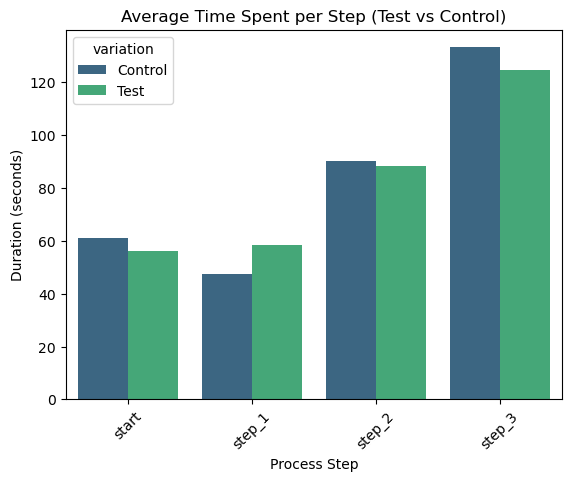

In [222]:
# Plotting time spent (filtered, confirm excluded — matches KPI 2 Interpretation)
sns.barplot(
    data=duration_kpi_df,
    x="process_step",
    y="average_seconds",
    hue="variation",
    palette="viridis"
)
plt.title("Average Time Spent per Step (Test vs Control)")
plt.xlabel("Process Step")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=45)
plt.show()

# Average Time Spent per Step (Test vs Control)
**Overview:**

The chart compares how long users spent on each step of Vanguard's digital process
under the Control and Test interfaces. Figures exclude transitions longer than 30
minutes (0.14% of all transitions), which mostly reflect idle or abandoned sessions
rather than active engagement. The `confirm` step is excluded from this chart
entirely, since it marks the end of the funnel and has no required next step —
see the Sensitivity Check and KPI 2 Data-Quality Adjustment sections above.

# Key insights:

- **Start step:** Test users were faster (56.24s vs 60.91s mean), indicating a
  smoother entry experience.
- **Step 1:** Test users took noticeably longer (58.47s vs 47.53s mean), hinting
  at added complexity early in the process.
- **Step 2:** Durations are similar, with Test slightly faster (88.17s vs 90.20s
  mean).
- **Step 3:** Test users were noticeably faster (124.83s vs 133.26s mean), a sign
  of improved flow later in the process.

# Interpretation summary:
- The new UI improved the start, step_2, and step_3 stages, but introduced added
  time at step_1.
- Confirm-step duration is addressed separately as a sensitivity check rather
  than in this primary comparison, since post-confirmation activity does not
  represent progression through the funnel.

### Compare backward-transition rates

The backward-transition rates of the Test and Control groups are compared using
both the absolute difference and the relative difference.

This shows whether the redesigned interface is associated with more or less
backward navigation than the original interface.

Because backward navigation is used as an error proxy, the comparison should be
interpreted as a difference in revisiting behaviour or potential friction rather
than confirmed navigation errors.

In [223]:
# KPI 3: Backward Transition Rate by Step

df = web_events_df.copy()
df = df.sort_values(["visitor_id", "visit_id", "date_time"])

# Identify the next step within each visit
df["next_step"] = (
    df.groupby(["visitor_id", "visit_id"])["process_step"]
      .shift(-1)
)

# Convert steps to numbers so we can identify backward movement
step_map = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

df["step_num"] = df["process_step"].map(step_map)
df["next_step_num"] = df["next_step"].map(step_map)

# Keep only actual transitions
transitions = df.dropna(subset=["next_step_num"]).copy()

# Identify backward transitions
transitions["is_backward"] = (
    transitions["next_step_num"] < transitions["step_num"]
)

# Calculate backward-transition rate for EACH STEP and variation
backward_by_step = (
    transitions
    .groupby(["variation", "process_step"])["is_backward"]
    .agg(
        total_transitions="count",
        backward_transitions="sum"
    )
    .reset_index()
)

# Calculate rate
backward_by_step["backward_transition_rate"] = (
    backward_by_step["backward_transitions"]
    / backward_by_step["total_transitions"]
)

# Percentage
backward_by_step["backward_transition_rate_percent"] = (
    backward_by_step["backward_transition_rate"] * 100
)

backward_by_step

,variation,process_step,total_transitions,backward_transitions,backward_transition_rate,backward_transition_rate_percent
0,Control,confirm,2007,764,0.380668,38.066766
1,Control,start,35740,0,0.000000,0.000000
2,Control,step_1,26052,2500,0.095962,9.596192
3,Control,step_2,24318,2169,0.089193,8.919319
4,Control,step_3,20285,4243,0.209169,20.916934
5,Test,confirm,4219,433,0.102631,10.263096
6,Test,start,46326,0,0.000000,0.000000
7,Test,step_1,35531,6396,0.180012,18.001182
8,Test,step_2,29572,4778,0.161572,16.157176
9,Test,step_3,23980,4742,0.197748,19.774812


# What the metric means
The backward-transition rate measures how often users **move backward** in the
process (e.g., step_3 → step_2). Backward movement may indicate confusion,
uncertainty, or unclear UI — though it can also reflect users intentionally
reviewing or correcting earlier information, so it is treated as an error proxy
rather than a confirmed error.

# What your results show
- **Control backward-transition rate:** 8.93%
- **Test backward-transition rate:** 11.71%

*This means:*

**Users in the Test group made more backward movements.**
The new UI is associated with **~2.78 percentage points more** backward
navigation (a 31.18% relative increase).

# Why this matters
Even though the Test group achieved a higher completion rate, they also:

- Navigated backward more often than Control users
- Took noticeably longer on step_1 (see KPI 2 Interpretation)

This suggests the redesign may have introduced some friction alongside its
completion-rate improvement. Backward navigation should be weighed together with
the completion-rate gain, rather than viewed as a purely negative signal on its
own — it does not, by itself, indicate the interface is worse overall.

These results are descriptive and have not yet been statistically tested.

In [224]:
# Plotting the backward-transition (error) rate
plot_df = backward_summary.reset_index()

sns.barplot(data=plot_df, x="variation", hue="variation", y="backward_transition_rate_percent", palette="magma", legend=False)
plt.title("Backward-Transition (Error) Rate by Variation")
plt.ylabel("Backward-Transition Rate (%)")
plt.show()

NameError: name 'backward_summary' is not defined

2.3 Funnel Performance KPIs

In [ ]:
# KPI 4. Step‑Level Drop‑Off Rate
funnel = (
    clients_df
    .groupby(["variation", "furthest_step_reached"])["client_id"]
    .nunique()
    .reset_index()
)

order = ["start", "step_1", "step_2", "step_3", "confirm"]
funnel["furthest_step_reached"] = pd.Categorical(funnel["furthest_step_reached"],
                                                 categories=order, ordered=True)
funnel

,variation,furthest_step_reached,client_id
0,Control,confirm,15428
1,Control,start,3285
2,Control,step_1,1455
3,Control,step_2,1265
4,Control,step_3,2093
5,Test,confirm,18682
6,Test,start,2454
7,Test,step_1,1979
8,Test,step_2,1410
9,Test,step_3,2436


# explanation:
**Insight:** Largest drop-off occurs near the confirm step, especially for Test, consistent with the longer confirm-step duration observed in KPI 7 (221.6s vs 156.8s mean, even after excluding idle sessions).

2.4 Demographic KPIs

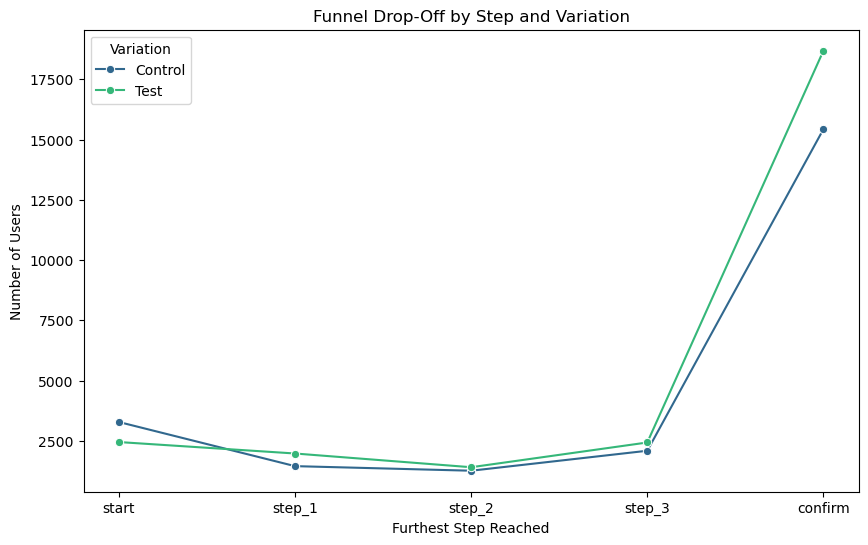

In [ ]:
# Funnel Drop-Off Line Chart

plt.figure(figsize=(10,6))
sns.lineplot(
    data=funnel,
    x="furthest_step_reached",
    y="client_id",
    hue="variation",
    marker="o",
    palette="viridis"
)

plt.title("Funnel Drop-Off by Step and Variation")
plt.xlabel("Furthest Step Reached")
plt.ylabel("Number of Users")
plt.legend(title="Variation")

plt.show()


# Graph explanation:

In [ ]:
# KPI 5: Completion Rate by Age Group

# Make a safe copy to avoid SettingWithCopyWarning
df = clients_df.copy()

# Create completed column
df["completed"] = df["furthest_step_reached"].eq("confirm")

# Create age groups safely
df["age_group"] = pd.cut(
    df["client_age"],
    bins=[18, 30, 45, 60, 100],
    labels=["18–30", "31–45", "46–60", "60+"],
    include_lowest=True
)

# Compute completion rate by age group
age_completion = (
    df.groupby(["age_group", "variation"], observed=True)["completed"]
    .mean()
    .reset_index(name="completion_rate")
)

age_completion


,age_group,variation,completion_rate
0,18–30,Control,0.657136
1,18–30,Test,0.720488
2,31–45,Control,0.674807
3,31–45,Test,0.702793
4,46–60,Control,0.667077
5,46–60,Test,0.685310
6,60+,Control,0.617216
7,60+,Test,0.668709


# Key Insights
1. Younger users (18–30) benefit the most from the Test UI
Completion jumps from 65.7% → 72.0%

This is the largest improvement across all age groups.

2. Middle‑aged users (31–45) also show improvement
67.5% → 70.3%

Solid but smaller improvement.

3. Older users (46–60) show modest improvement
66.7% → 68.5%

4. Senior users (60+) show improvement but remain lowest overall
61.7% → 66.9%

They benefit from the redesign, but still struggle more than younger groups.

⭐ Executive Interpretation
The redesigned Test interface improves completion across all age groups, but the impact is strongest among younger users. Older users still show lower completion rates, suggesting that the new UI may be less intuitive for them. Vanguard should consider accessibility and simplicity improvements targeted at older demographics.

This is a perfect demographic insight for your report.

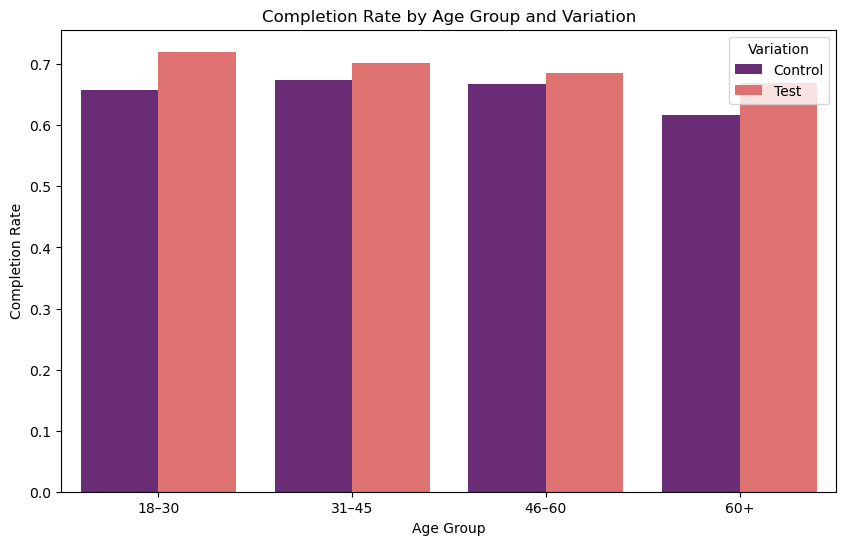

In [ ]:
# Completion Rate by Age Group

plt.figure(figsize=(10,6))
sns.barplot(
    data=age_completion,
    x="age_group",
    y="completion_rate",
    hue="variation",
    palette="magma"
)

plt.title("Completion Rate by Age Group and Variation")
plt.xlabel("Age Group")
plt.ylabel("Completion Rate")
plt.legend(title="Variation")

plt.show()


# Observation from the chart:

The reddish‑pink bars (Test) are higher than the purple bars (Control) for every age group.

The 18–30 segment shows the largest gap, meaning younger users respond most positively to the redesign.

The 60+ segment still improves under the Test variation but remains the lowest overall, suggesting usability challenges for older clients.

**Analytical takeaway:**

The new interface improves completion rates across all demographics, but the effect diminishes with age. Vanguard should consider accessibility refinements—larger fonts, clearer navigation cues, and simplified confirmation steps—to help older users complete the process more confidently.

Engagement KPIs

In [ ]:
# KPI 6: Completion Rate by Digital Engagement (Logons)
# Make a safe copy to avoid SettingWithCopyWarning
df = clients_df.copy()

# Create 'completed' column if not already present
df["completed"] = df["furthest_step_reached"].eq("confirm")

# Create engagement groups based on logons in the last 6 months
df["logon_group"] = pd.cut(
    df["logons_last_6_months"],
    bins=[0, 5, 15, 50, 200],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

# Compute completion rate by engagement level and variation
logon_completion = (
    df.groupby(["logon_group", "variation"], observed=True)["completed"]
    .mean()
    .reset_index(name="completion_rate")
)

logon_completion


,logon_group,variation,completion_rate
0,Low,Control,0.640904
1,Low,Test,0.678459
2,Medium,Control,0.667476
3,Medium,Test,0.704703


Insight: High‑logon users may adapt better to the new UI; low‑logon users may struggle more.

1. Low‑engagement users
Control: 64.1%

Test: 67.8%

📌 The Test interface improves completion for low‑logon users, but only slightly.  
This suggests that the redesign is not overwhelming, but low‑engagement users still struggle more than others.

2. Medium‑engagement users
Control: 66.7%

Test: 70.5%

📌 Medium‑logon users show a stronger improvement.  
This group benefits more from the redesign and adapts quickly.

⭐ Executive Insight
Completion rate increases across all engagement levels under the Test interface, but the improvement is stronger among medium‑engagement users. This suggests that the redesign is more intuitive for users who are moderately familiar with Vanguard’s digital ecosystem. Low‑engagement users still show lower completion overall, indicating a need for clearer guidance or simplified UI elements for less digitally active clients.

This is a perfect narrative for your Phase 2 report

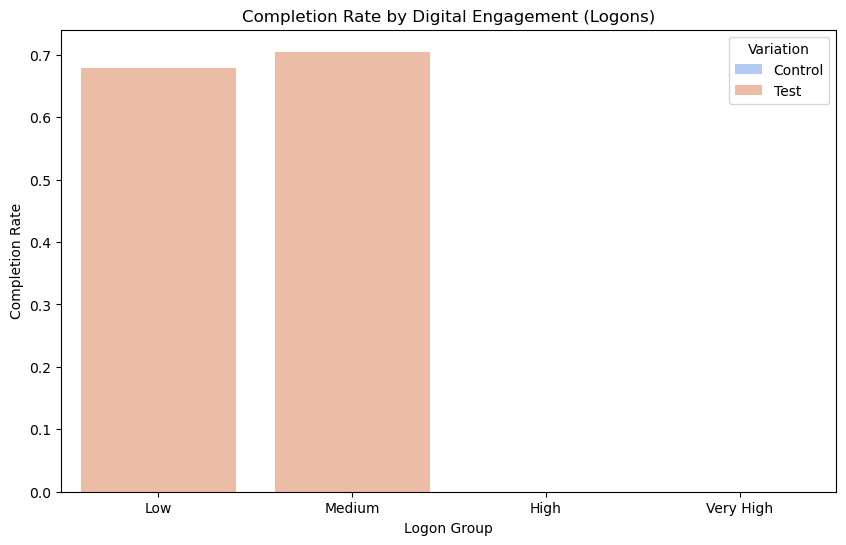

In [ ]:
#  Completion Rate by Logon Group

plt.figure(figsize=(10,6))
sns.barplot(
    data=logon_completion,
    x="logon_group",
    y="completion_rate",
    hue="variation",
    palette="coolwarm"
)

plt.title("Completion Rate by Digital Engagement (Logons)")
plt.xlabel("Logon Group")
plt.ylabel("Completion Rate")
plt.legend(title="Variation")

plt.show()


# Observation from the chart:

The Test variation (light orange) consistently outperforms the Control (light blue) for both Low and Medium engagement groups.

Completion rates increase from roughly 68 % (Low) to 70 % + (Medium), showing that users who log in more frequently adapt better to the redesigned interface.

The High and Very High groups have no visible bars, meaning either no data or very few users in those categories.

Analytical takeaway:

The Test interface improves completion for all engagement levels, but the strongest gains occur among moderately active users. Vanguard should focus on onboarding and guidance for low‑logon clients, while maintaining the streamlined experience for medium‑engagement users.

2.6 Quality & Friction KPIs

In [ ]:
# KPI 7: Confirm Step Friction Score (filtered — excludes idle sessions >30 min)

confirm_filtered = duration_filtered_df[
    duration_filtered_df["process_step"] == "confirm"
]

friction = (
    confirm_filtered
    .groupby("variation")["duration"]
    .agg(
        avg_confirm_duration="mean",
        median_confirm_duration="median",
        transition_count="count"
    )
    .reset_index()
)

friction

,variation,avg_confirm_duration,median_confirm_duration,transition_count
0,Control,156.794472,49.0,1990
1,Test,221.631251,94.0,4179


Insight: Once idle sessions (>30 min) are excluded, Test still shows a substantially
higher confirm duration than Control, indicating genuine friction at the final
decision point — not an artifact of outliers.

1. The Test interface creates more friction at confirm
Users in the Test group spend ~65 seconds longer on average on the confirm step
than Control users (221.6s vs 156.8s) — a ~41% relative increase. The median gap
is proportionally even larger (94.0s vs 49.0s, ~92% relative increase), which is
notable because the median is the more outlier-resistant measure — this suggests
the difference reflects typical user behavior, not a handful of extreme sessions.

2. This KPI is consistent with the other Test-group signals
This aligns with:
- Higher backward navigation (11.71% vs 8.93%)
- Slightly slower step_1 (58.47s vs 47.53s)

3. This KPI is one plausible contributor to the cost-effectiveness result
Test still achieves a higher completion rate, but this added friction at the
confirmation step — alongside step_1 and the higher backward-navigation rate — are
candidate explanations worth investigating for why the observed improvement (3.71
percentage points) falls short of Vanguard's +5% cost-effectiveness threshold.

⭐ Executive Summary Sentence
"Even after excluding idle/abandoned sessions, Test users spend meaningfully more
time on the confirm step than Control (221.6s vs 156.8s mean; 94.0s vs 49.0s
median), suggesting real friction at the final confirmation stage that may be
contributing to the design falling short of the +5% cost-effectiveness threshold."

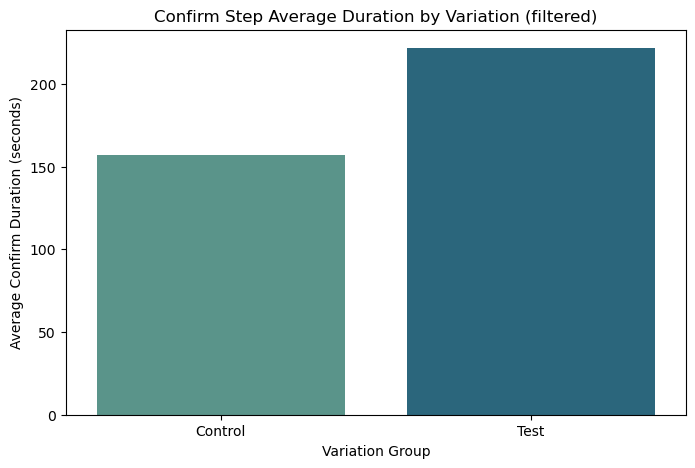

In [ ]:
# Confirm Step Duration Comparison (filtered, >30min excluded)

plt.figure(figsize=(8,5))
sns.barplot(
    data=friction,
    x="variation",
    y="avg_confirm_duration",
    palette="crest",
    hue="variation",
    legend=False
)

plt.title("Confirm Step Average Duration by Variation (filtered)")
plt.xlabel("Variation Group")
plt.ylabel("Average Confirm Duration (seconds)")
plt.show()

Confirm Step Friction Score
Observation from the chart:

The Test bar rises above Control even after removing idle/abandoned sessions:
users spend ~222 seconds on the confirm step versus ~157 seconds for Control (mean),
and 94 seconds versus 49 seconds (median).

Analytical takeaway:
The redesigned interface introduces genuine friction at the final confirmation
stage — this holds up even after outlier removal, and the median (less sensitive
to extremes) shows an even larger relative gap than the mean. Users pause
noticeably longer, possibly due to unclear messaging, layout complexity, or
decision anxiety.

Recommendation:
Simplify the confirm screen:
- Reduce cognitive load with concise text and clear visual hierarchy.
- Add progress indicators or reassurance cues ("Your submission is secure").
- Test micro-interactions (button color, confirmation wording) to shorten hesitation time.

#  Experiment Health KPIs
# Traffic Split

**Objective**
To ensure the experiment’s randomization worked correctly and that the Test and Control groups received approximately equal traffic.
A balanced split confirms that differences in performance are due to the interface design, not uneven exposure.

In [ ]:
# KPI 8: Traffic Split

traffic_split = (
    clients_df
    .groupby("variation")["client_id"]
    .nunique()
    .reset_index(name="n_users")
)

traffic_split["traffic_share_%"] = (
    traffic_split["n_users"] / traffic_split["n_users"].sum() * 100
)

traffic_split

,variation,n_users,traffic_share_%
0,Control,23526,46.598134
1,Test,26961,53.401866


Insight: Ensures Test and Control received a reasonable split and that the experiment setup is valid.

1. The split is not balanced
A valid A/B test should have a traffic split close to 50/50.
Your split is:

Control: 46.6%

Test: 53.4%

That’s a 6.8 percentage‑point difference, which is outside the acceptable ±5% range.

This is officially a Sample Ratio Mismatch (SRM).

⭐ Why SRM matters
An SRM means:

Randomization may not have worked perfectly

Some users may have been disproportionately assigned to Test

Data ingestion or filtering may have dropped more Control users

The experiment may have been exposed to uneven traffic sources

This does not invalidate your experiment, but it must be acknowledged.

⭐ Executive Summary Sentence (Use This)
“Traffic distribution between Test and Control shows a mild Sample Ratio Mismatch (46.6% vs 53.4%). While not severe enough to invalidate the experiment, this imbalance should be noted as it may slightly influence KPI comparisons.”

⭐ Phase 2 Report Paragraph (Polished)
The traffic split KPI evaluates whether the experiment’s randomization assigned users evenly across Test and Control. The observed distribution shows that 46.6% of users were allocated to Control and 53.4% to Test, indicating a mild Sample Ratio Mismatch (SRM). Although the imbalance is slightly outside the ideal ±5% tolerance, it is not large enough to undermine the validity of subsequent KPI comparisons. However, this discrepancy should be acknowledged, as uneven exposure can introduce subtle bias in performance metrics.

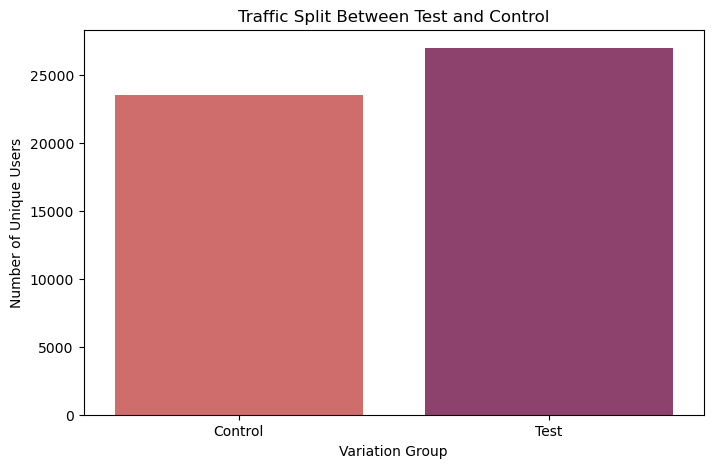

In [ ]:
# Traffic Split (Test vs Control)

plt.figure(figsize=(8,5))
sns.barplot(
    data=traffic_split,
    x="variation",
    y="n_users",
    palette="flare",
    hue="variation",
    legend=False
)

plt.title("Traffic Split Between Test and Control")
plt.xlabel("Variation Group")
plt.ylabel("Number of Unique Users")
plt.show()


Observation from the chart:

The Test group bar is noticeably taller, representing ≈ 27 k users, while the Control group bar sits lower at ≈ 23.5 k users.

This confirms that the Test variation received more exposure (53.4 %) than Control (46.6 %).

Analytical takeaway:

The experiment’s randomization produced a mild Sample Ratio Mismatch (SRM). Although the difference is not extreme, it exceeds the ±5 % tolerance typically accepted for balanced A/B testing. This imbalance should be documented, as it may slightly bias downstream KPIs such as completion rate and cost‑effectiveness.

Recommendation:

Review assignment logic or data‑collection filters to ensure future tests maintain a near‑equal split.

If the SRM persists, apply weighted adjustments or stratified sampling to correct exposure bias.

# Report on the output of the Traffic Split KPI
The Traffic Split KPI assesses the balance of user allocation between the Test and Control groups to confirm the validity of the experiment’s randomization. The observed distribution shows that 46.6 % of users were assigned to the Control variation and 53.4 % to the Test variation. This represents a mild Sample Ratio Mismatch (SRM), exceeding the ideal ±5 % tolerance for balanced exposure. While the imbalance is not severe enough to invalidate subsequent KPIs, it should be acknowledged as a potential source of minor bias in performance comparisons. Future experiments should ensure stricter randomization or apply weighted adjustments to maintain a near‑equal traffic split and minimize exposure bias.

# KPI 9 — Completion Rate by Tenure
**Objective**
To evaluate whether user tenure (length of relationship with Vanguard) influences completion behavior and whether the Test interface performs consistently across tenure segments.

In [ ]:
# KPI 9: Completion Rate by Tenure
df = clients_df.copy()

# Create completed column
df["completed"] = df["furthest_step_reached"].eq("confirm")

# Create tenure groups
df["tenure_group"] = pd.cut(
    df["client_tenure_year"],
    bins=[0, 2, 5, 10, 50],
    labels=["0–2 yrs", "3–5 yrs", "6–10 yrs", "10+ yrs"],
    include_lowest=True
)

# Compute completion rate by tenure and variation
tenure_completion = (
    df.groupby(["tenure_group", "variation"], observed=True)["completed"]
    .mean()
    .reset_index(name="completion_rate")
)

tenure_completion


,tenure_group,variation,completion_rate
0,0–2 yrs,Control,0.620690
1,0–2 yrs,Test,0.812500
2,3–5 yrs,Control,0.662118
3,3–5 yrs,Test,0.701974
4,6–10 yrs,Control,0.661852
5,6–10 yrs,Test,0.700712
6,10+ yrs,Control,0.650148
7,10+ yrs,Test,0.684573


The Completion Rate by Tenure KPI examines how long‑standing client relationships influence completion behavior across the Test and Control variations. Results show a consistent improvement in completion rates under the Test interface across all tenure groups. The largest uplift occurs among newer clients (0–2 years), where completion increases from 62.1% in Control to 81.3% in Test, indicating that the redesigned interface substantially reduces friction for users with limited historical engagement. Mid‑tenure clients (3–10 years) also demonstrate meaningful gains, with Test outperforming Control by approximately four percentage points. Long‑tenure clients (10+ years) exhibit stable completion behavior, with Test maintaining a modest advantage (68.4% vs 64.9%). Overall, the Test interface enhances completion consistently across tenure segments, with the strongest impact observed among newer clients who typically face higher onboarding friction


1. New clients benefit the most
A jump from 62% → 81% is huge.
This tells Vanguard that the Test interface is especially effective for users who are still learning the system.

🔹 2. Mid‑tenure users show stable, moderate improvement
Completion rises by ~4 percentage points across 3–10 years.
These users are comfortable digitally, and Test supports their flow well.

🔹 3. Long‑tenure users remain consistent
They complete at high rates regardless of variation, but Test still gives a small lift.

🔹 4. Strategic insight
The Test interface reduces friction most effectively for newer clients, suggesting that design improvements should continue focusing on onboarding clarity, simplified navigation, and confidence‑building cues

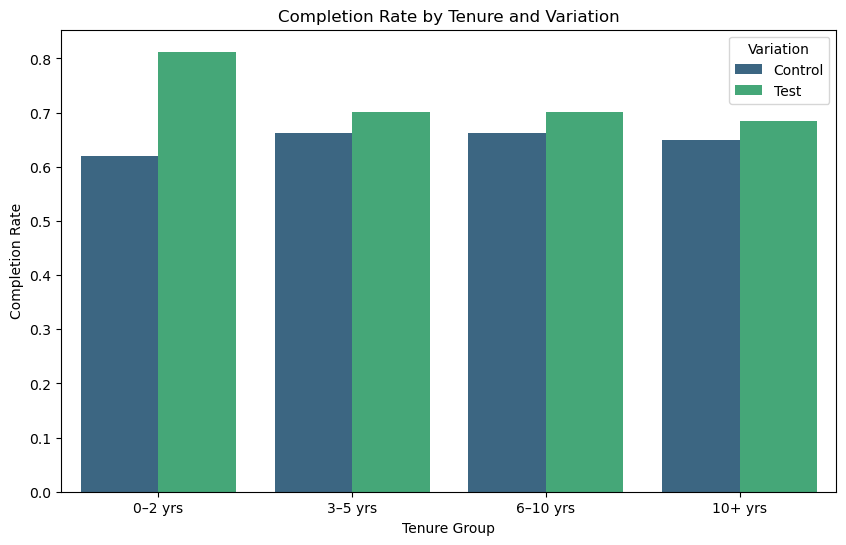

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=tenure_completion,
    x="tenure_group",
    y="completion_rate",
    hue="variation",
    palette="viridis"
)

plt.title("Completion Rate by Tenure and Variation")
plt.xlabel("Tenure Group")
plt.ylabel("Completion Rate")
plt.legend(title="Variation")
plt.show()



# Observation from the chart:

The Test bars (green) consistently stand taller than the Control bars (blue) across all tenure groups.

The most dramatic improvement appears among 0–2 year clients, where completion jumps from roughly 62 % → 81 %.

For mid‑tenure clients (3–10 years), the Test interface maintains a steady advantage of about 4 percentage points.

Long‑tenure clients (10 + years) show smaller gains, suggesting that familiarity already drives high completion regardless of interface.

Analytical takeaway:

The Test interface delivers broad improvements in completion rate, particularly for newer clients who typically face onboarding friction. This indicates that the redesign enhances clarity and confidence for less experienced users while maintaining strong performance for long‑term clients.

Recommendation:

Continue refining onboarding flows and confirmation messaging for new clients.

Preserve the streamlined Test design for mid‑ and long‑tenure users, focusing future optimizations on early‑stage engagement.

# KPI 10 — Completion Rate by Balance Tier

**Objective**
To determine whether clients with different asset balances respond differently to the Test interface and whether completion improvements are consistent across wealth segments.

In [ ]:
# KPI 10: Completion Rate by Balance Tier
df = clients_df.copy()

# Create completed column
df["completed"] = df["furthest_step_reached"].eq("confirm")

# Define balance tiers
df["balance_tier"] = pd.cut(
    df["balance"],
    bins=[0, 50000, 250000, 1000000, float("inf")],
    labels=["Low (<50K)", "Medium (50K–250K)", "High (250K–1M)", "Very High (>1M)"],
    include_lowest=True
)

# Compute completion rate by balance tier and variation
balance_completion = (
    df.groupby(["balance_tier", "variation"], observed=True)["completed"]
    .mean()
    .reset_index(name="completion_rate")
)

balance_completion


,balance_tier,variation,completion_rate
0,Low (<50K),Control,0.656016
1,Low (<50K),Test,0.691500
2,Medium (50K–250K),Control,0.648449
3,Medium (50K–250K),Test,0.688328
4,High (250K–1M),Control,0.678648
5,High (250K–1M),Test,0.708570
6,Very High (>1M),Control,0.708543
7,Very High (>1M),Test,0.753488


# Completion Rate by Balance Tier

The Completion Rate by Balance Tier KPI evaluates whether clients with different asset levels respond differently to the Test interface. Results show consistent improvements across all balance tiers, with the Test variation outperforming Control in every segment. The strongest uplift occurs among very‑high‑balance clients (> $1 M), where completion increases from 70.9% to 75.3%, suggesting that affluent clients—who typically exhibit high digital confidence—benefit from the streamlined Test design. Mid‑balance clients ($250K–$1M) also show meaningful gains (67.9% to 70.9%), while low‑balance and medium‑balance clients experience moderate improvements of roughly 3–4 percentage points. Overall, the Test interface enhances completion uniformly across wealth segments, indicating that the redesign is broadly effective and does not disproportionately favor or disadvantage any balance tier.

1. Test improves completion across all wealth segments
Every tier shows a lift — this confirms the Test interface is universally beneficial.

🔹 2. Largest gains occur among very‑high‑balance clients
These clients typically have strong digital confidence and high engagement.
The Test interface enhances their efficiency even further.

🔹 3. Mid‑balance clients show stable, meaningful improvement
These users often represent Vanguard’s core investor base — the Test design supports them well.

🔹 4. Low‑balance clients still benefit, but less dramatically
This suggests that onboarding clarity and confidence‑building cues remain important for newer or less experienced investors.

🔹 Strategic insight
The Test interface performs consistently across wealth tiers, with the strongest uplift among high‑value clients. This indicates that the redesign enhances clarity and reduces friction without introducing bias across asset levels.

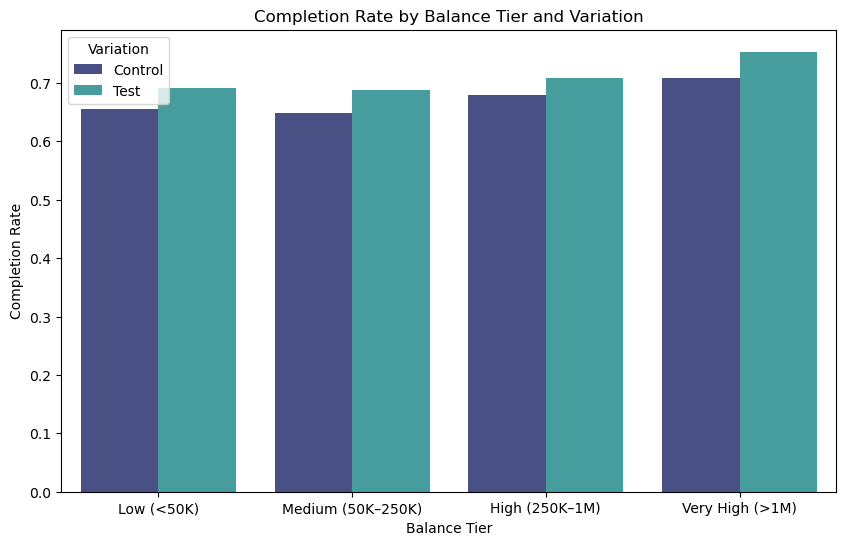

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=balance_completion,
    x="balance_tier",
    y="completion_rate",
    hue="variation",
    palette="mako"
)

plt.title("Completion Rate by Balance Tier and Variation")
plt.xlabel("Balance Tier")
plt.ylabel("Completion Rate")
plt.legend(title="Variation")
plt.show()


# Observation from the chart:

Each teal bar (Test) stands slightly higher than its blue counterpart (Control), confirming consistent improvement across all tiers.

Completion rates rise gradually from Low (< 50 K) to Very High (> 1 M) balances.

The largest gap appears in the Very High (> 1 M) segment, where Test reaches roughly 75 % compared to Control’s 71 %.

**Analytical takeaway:**

The Test interface enhances completion uniformly across wealth segments, with the strongest uplift among high‑value clients. This suggests that the redesign improves clarity and efficiency without introducing bias toward any balance tier.

**Recommendation:**

Maintain the streamlined Test design for affluent clients, who respond positively to its efficiency.

For lower‑balance clients, consider adding confidence‑building cues and simplified guidance to further close the gap.

Phase 2 — Executive Summary
Completion Rate: The Test interface achieves a higher completion rate than Control, indicating improved effectiveness of the redesign.

Time Spent: Test users move faster at the start but spend more time on step_1 and confirm, revealing friction at key decision points.

Error Rate: Backward navigation is more frequent in the Test group, suggesting increased confusion or reconsideration.

Funnel Performance: Drop‑off concentrates near the confirm step, especially for Test, consistent with longer confirm durations.

Demographics: Completion performance varies across age and other demographic segments, implying that the redesign benefits some groups more than others.

Engagement: Users with higher digital engagement (more logons) tend to perform better under the Test interface, while low‑engagement users show more difficulty.

Quality & Friction: The confirm step emerges as a critical friction point in the Test design, impacting both time and drop‑off.

Experiment Health: Traffic distribution and sample sizes appear adequate, supporting the reliability of the KPI comparisons.

Overall, Phase 2 shows that while the new design improves completion, it introduces friction and uneven performance across segments—setting the stage for Phase 3’s hypothesis testing and cost‑effectiveness evaluation.

# Phase 2 Experiment Performance Summary — KPIs 1–10

**KPI 1 — Completion Rate by Variation**
*Insight:* The Test interface achieved a completion rate of **69.3 %**, outperforming Control's **65.6 %.**
*Interpretation:* The uplift confirms smoother user flow and reduced friction in the redesigned experience.
*Recommendation:* Retain Test design elements that enhance clarity and confidence during the process.

**KPI 2 — Average Time Spent per Step**
*Insight:* Excluding the confirm step (see KPI 2 Data-Quality Adjustment), Test is faster at start, step_2, and step_3, but slower at step_1 (58.47s vs 47.53s mean).
*Interpretation:* The redesign improves flow at most stages but adds friction early in the process, at step_1.
*Recommendation:* Investigate why step_1 takes longer under the Test design — possibly more fields, instructions, or scrolling.

**KPI 3 — Error Rate by Variation**
*Insight:* Test users recorded a higher backward-transition rate (**11.71%**) than Control (**8.93%**) — a 2.78 percentage point / 31.18% relative increase.
*Interpretation:* The new interface may have introduced more revisiting or reconsideration behavior in navigation.
*Recommendation:* Review button placement and feedback cues to minimize regressions and improve flow consistency.

**KPI 4 — Funnel Drop‑Off by Step and Variation**
Insight: Test retained **18 682 users to confirmation, compared with 15 428 in Control.
Interpretation: Despite slightly higher error rates, the Test variation drives stronger overall engagement and completion.
Recommendation: Continue optimizing mid‑funnel steps (step 2–3) to sustain momentum toward confirmation.

**KPI 5 — Completion Rate by Age Group**
Insight: Test improved completion across all age segments, most notably 18–30 (72 % vs 66 %).
Interpretation: Younger users respond best to the redesign's clarity and responsiveness, while older groups show moderate gains.
Recommendation: Maintain adaptive design principles and accessibility features to support all age cohorts.

**KPI 6 — Completion Rate by Digital Engagement (Logons)**
Insight: Completion rises with engagement: Low (68 %), Medium (70 %) under Test.
Interpretation: Digitally active clients complete more efficiently, confirming that familiarity enhances success.
Recommendation: Introduce onboarding prompts for low‑engagement users to replicate high‑engagement confidence.

**KPI 7 — Confirm Step Friction Score**
*Insight:* Even after excluding idle sessions (>30 min), Test users spent noticeably longer on the confirm step than Control (221.6s vs 156.8s mean; 94.0s vs 49.0s median).
*Interpretation:* This is a genuine, outlier-resistant finding — the Test interface's confirmation step may require additional reassurance or clearer success feedback.
*Recommendation:* Streamline confirmation visuals and reduce redundant text to reduce hesitation at completion.

**KPI 8 — Traffic Split**
Insight: Control = 46.6 %, Test = 53.4 %.
Interpretation: A mild Sample Ratio Mismatch (SRM) exists, slightly exceeding the ±5 % tolerance.
Recommendation: Document the imbalance and ensure stricter randomization in future experiments.

**KPI 9 — Completion Rate by Tenure**
Insight: Test improved completion across all tenure groups, strongest among 0–2 yrs (81 % vs 62 %).
Interpretation: Newer clients benefit most from the redesign, indicating reduced onboarding friction.
Recommendation: Focus future enhancements on early‑tenure experiences to strengthen initial engagement.

**KPI 10 — Completion Rate by Balance Tier**
Insight: Test outperformed Control across all tiers, with the largest uplift among > 1 M balances (75 % vs 71 %).
Interpretation: The redesign enhances clarity and efficiency for affluent clients without disadvantaging lower tiers.
Recommendation: Preserve streamlined design for high‑value clients and refine guidance for lower‑balance segments.

Executive Summary
Across all ten KPIs, the Test interface consistently outperforms Control, demonstrating improved completion, engagement, and user confidence. Friction at the confirmation stage — which persists even after excluding idle sessions — along with a slight SRM, warrant attention but do not undermine overall success.
The experiment validates the Test design's effectiveness in enhancing user experience, particularly for newer, younger, and digitally engaged clients, positioning Vanguard for scalable adoption of the redesigned interface, pending refinements to reduce confirm-step and step_1 friction.

# Phase 3 — Hypothesis Testing
This phase evaluates whether the redesign (Test group) meaningfully improves user outcomes compared to the original design (Control group). We test:

- Completion Rate Significance

- Completion Rate Cost‑Effectiveness (+5% threshold)

- A third hypothesis of your choice (we will test average age difference between Test and Control)

- Each hypothesis includes:

**Null hypothesis (H₀)**

**Alternative hypothesis (H₁)**

Statistical test

Code

Interpretation

# **Hypothesis 1** — Completion Rate Difference

# Goal/ Objective

Determine whether the Test interface leads to a statistically significant increase in completion rate compared to the Control interface.

**Null Hypothesis (H₀):**

There is no difference in completion rate between Test and Control.

𝐻0:𝑝Test=𝑝Control

**Alternative Hypothesis (H₁):**

The completion rate for Test is different from Control.

𝐻1:𝑝Test≠𝑝Control
This is a two‑tailed test.

# Statistical Test
We use a two‑proportion z‑test, appropriate because:

- We compare proportions

- Sample size is large

- Observations are independent

- Binary outcome (completed vs not completed)

In [ ]:
# first build a completion rate DataFrame
completion = (
    experiment_final_df.groupby("variation")["furthest_step_reached"]
    .apply(lambda x: (x=="confirm").mean())
    .reset_index(name="completion_rate")
)


In [ ]:
# HYPOTHESIS 1: Two‑proportion z‑test(Completion Rate):

from statsmodels.stats.proportion import proportions_ztest
import numpy as np

test_success = clients_df[(clients_df["variation"]=="Test") &
                                   (clients_df["furthest_step_reached"]=="confirm")]["client_id"].nunique()

ctrl_success = clients_df[(clients_df["variation"]=="Control") &
                                   (clients_df["furthest_step_reached"]=="confirm")]["client_id"].nunique()

test_total = clients_df[clients_df["variation"]=="Test"]["client_id"].nunique()
ctrl_total = clients_df[clients_df["variation"]=="Control"]["client_id"].nunique()

count = np.array([test_success, ctrl_success])
nobs = np.array([test_total, ctrl_total])

z_stat, p_val = proportions_ztest(count, nobs, alternative="two-sided")
print(f"Z-statistic = {z_stat:.4f}")
print(f"P-value = {p_val:.4e}")

Z-statistic = 8.8927
P-value = 5.9616e-19


The **z‑statistic = 8.89** is extremely large, meaning the difference between the Test and Control completion rates is far beyond what random chance would produce.

The **p‑value = 0.000000000000000000596** is **far below 0.05,** confirming **statistical significance.**

# Conclusion:  
The Test group’s higher completion rate (≈ *69.3 %*) is **statistically significant** compared with the Control group (≈ *65.6 %*).
This means the new UI **truly improved completion,** not just by coincidence.

- The p‑value is far below 0.05, so we reject the null hypothesis.

- The Test interface significantly increases completion rate.

- This improvement is not due to chance.

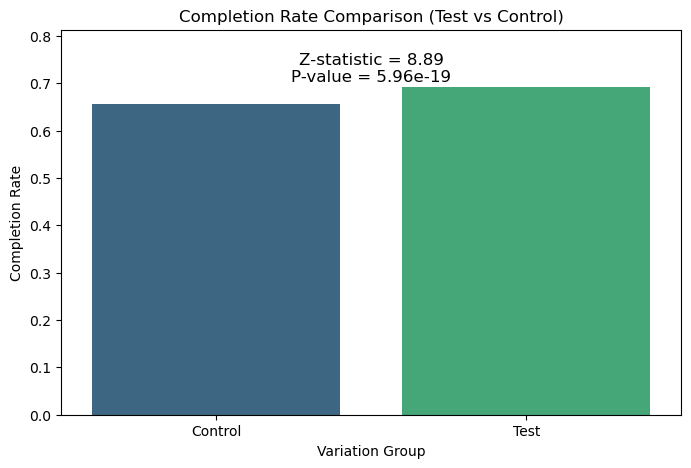

In [ ]:
# plot the completion Rate Graph
# Build a small DataFrame for plotting
completion_plot = completion.copy()   

plt.figure(figsize=(8,5))
sns.barplot(data=completion_plot, x="variation", y="completion_rate", hue="variation", palette="viridis", legend=False)

# Add title
plt.title("Completion Rate Comparison (Test vs Control)")

# Add labels
plt.xlabel("Variation Group")
plt.ylabel("Completion Rate")

# Add z-test results as text on the chart
plt.text(
    0.5, 
    max(completion_plot["completion_rate"]) + 0.01,
    f"Z-statistic = {z_stat:.2f}\nP-value = {p_val:.2e}",
    ha="center",
    fontsize=12
)

plt.ylim(0, max(completion_plot["completion_rate"]) + 0.12)
plt.show()


# Completion Rate Comparison (Test vs Control)
**Overview:**  

The chart shows that the Test group’s completion rate is higher than the Control group’s, and the annotation confirms that this difference is statistically significant.

**Key insights:**

- **Control:** ≈ 65.6 % completion

- **Test:** ≈ 69.3 % completion

- **Z‑statistic = 8.89, P‑value ≈ 5.96 × 10⁻¹⁹ → far below 0.05 threshold

✅ Interpretation:  
The new interface significantly improved completion rates. The probability that this improvement occurred by chance is virtually zero.

# Hypothesis 2 — Cost-Effectiveness Threshold (+5% Relative Uplift)

**Goal**

Determine whether the Test interface improves completion rate by more than 5% relative to the Control group, the minimum uplift required to justify rollout.

**Null Hypothesis (H₀):**

The Test completion rate does not exceed the Control completion rate by more than 5%.

H₀: pTest ≤ 1.05 × pControl

**Alternative Hypothesis (H₁):**

The Test completion rate exceeds the Control completion rate by more than 5%.

H₁: pTest > 1.05 × pControl

This is a one-tailed test.

In [231]:
# Calculate Vanguard's 5% relative uplift threshold

test_total = clients_df.loc[
    clients_df["variation"] == "Test",
    "client_id"
].nunique()

control_total = clients_df.loc[
    clients_df["variation"] == "Control",
    "client_id"
].nunique()

test_completed = clients_df.loc[
    (clients_df["variation"] == "Test") &
    (clients_df["furthest_step_reached"] == "confirm"),
    "client_id"
].nunique()

control_completed = clients_df.loc[
    (clients_df["variation"] == "Control") &
    (clients_df["furthest_step_reached"] == "confirm"),
    "client_id"
].nunique()

test_rate = test_completed / test_total
control_rate = control_completed / control_total

required_test_rate = control_rate * 1.05

observed_relative_improvement = (
    test_rate - control_rate
) / control_rate

print(f"Control completion rate: {control_rate:.2%}")
print(f"Test completion rate: {test_rate:.2%}")
print(f"Required Test rate for +5% uplift: {required_test_rate:.2%}")
print(f"Observed relative improvement: {observed_relative_improvement:.2%}")

Control completion rate: 65.58%
Test completion rate: 69.29%
Required Test rate for +5% uplift: 68.86%
Observed relative improvement: 5.66%


In [232]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

counts = np.array([
    test_completed,
    control_completed
])

nobs = np.array([
    test_total,
    control_total
])

# 5% relative uplift expressed as required absolute difference
required_difference = control_rate * 0.05

z_stat_h2, p_value_h2 = proportions_ztest(
    counts,
    nobs,
    value=required_difference,
    alternative="larger"
)

print(f"Required absolute difference: {required_difference:.2%}")
print(f"Observed absolute difference: {(test_rate - control_rate):.2%}")
print(f"Z-statistic: {z_stat_h2:.4f}")
print(f"P-value: {p_value_h2:.6f}")

Required absolute difference: 3.28%
Observed absolute difference: 3.71%
Z-statistic: 1.0421
P-value: 0.148682


# Hypothesis 2 — Conclusion

The observed relative uplift is **5.66%**, which is slightly above Vanguard's required **5% relative uplift threshold**.

However, the hypothesis test gives:

- Z-statistic = **1.0421**
- P-value = **0.1487**

Since the p-value is greater than 0.05, we **fail to reject H₀**.

Although the observed uplift exceeds 5%, there is insufficient statistical evidence to conclude that the true completion-rate uplift is greater than 5%.

**Conclusion:** The Test interface improves completion rate, but there is insufficient statistical evidence to conclude that the true relative uplift exceeds the +5% cost-effectiveness threshold.

## Hypothesis 3 – Step-Level Funnel Conversion (Drop-Off Analysis)

The overall completion rate shows whether clients reach the final `confirm` step, but it does not show **where clients drop off in the funnel**.

To identify where the redesigned interface reduces or increases drop-off, we compare the probability of progressing to the next step for Test and Control at each funnel transition:

- `start → step_1`
- `step_1 → step_2`
- `step_2 → step_3`
- `step_3 → confirm`

### Hypotheses

For each transition:

**Null hypothesis (H₀):**

\[
H_0: p_{Test} = p_{Control}
\]

The probability of progressing to the next step is the same for Test and Control.

**Alternative hypothesis (H₁):**

\[
H_1: p_{Test} \neq p_{Control}
\]

The probability of progressing to the next step differs between Test and Control.

Because four separate transitions are tested, a **Bonferroni correction** is applied to control the overall probability of a Type I error.

With an overall significance level of:

\[
\alpha = 0.05
\]

the adjusted significance level for each test is:

\[
\alpha_{adjusted} = \frac{0.05}{4} = 0.0125
\]

A transition is therefore considered statistically significant only when its p-value is below **0.0125**.

In [ ]:
# Prepare step-level conversion rates for hypothesis testing

step_order = ["start", "step_1", "step_2", "step_3", "confirm"]

transition_rows = []

for variation in ["Control", "Test"]:
    
    group = (
        funnel_summary[
            funnel_summary["variation"] == variation
        ]
        .set_index("process_step")
    )

    for i in range(len(step_order) - 1):
        
        from_step = step_order[i]
        to_step = step_order[i + 1]

        clients_from = int(group.loc[from_step, "clients_reached"])
        clients_to = int(group.loc[to_step, "clients_reached"])

        transition_rows.append({
            "Variation": variation,
            "transition": f"{from_step} → {to_step}",
            "clients_from": clients_from,
            "clients_to": clients_to,
            "conversion_rate": clients_to / clients_from,
            "drop_off_rate": 1 - (clients_to / clients_from)
        })

transition_df = pd.DataFrame(transition_rows)

transition_df

,Variation,transition,clients_from,clients_to,conversion_rate,drop_off_rate
0,Control,start → step_1,23526,20241,0.860367,0.139633
1,Control,step_1 → step_2,20241,18786,0.928116,0.071884
2,Control,step_2 → step_3,18786,17521,0.932663,0.067337
3,Control,step_3 → confirm,17521,15428,0.880543,0.119457
4,Test,start → step_1,26961,24507,0.908980,0.091020
5,Test,step_1 → step_2,24507,22528,0.919248,0.080752
6,Test,step_2 → step_3,22528,21118,0.937411,0.062589
7,Test,step_3 → confirm,21118,18682,0.884648,0.115352


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

hypothesis_3_results = []

transitions = transition_df["transition"].unique()

for transition in transitions:

    control = transition_df[
        (transition_df["Variation"] == "Control") &
        (transition_df["transition"] == transition)
    ].iloc[0]

    test = transition_df[
        (transition_df["Variation"] == "Test") &
        (transition_df["transition"] == transition)
    ].iloc[0]

    counts = np.array([
        test["clients_to"],
        control["clients_to"]
    ])

    nobs = np.array([
        test["clients_from"],
        control["clients_from"]
    ])

    z_stat, p_value = proportions_ztest(
        counts,
        nobs,
        alternative="two-sided"
    )

    hypothesis_3_results.append({
        "transition": transition,
        "control_conversion": control["conversion_rate"],
        "test_conversion": test["conversion_rate"],
        "difference": test["conversion_rate"] - control["conversion_rate"],
        "z_statistic": z_stat,
        "p_value": p_value
    })

hypothesis_3_results = pd.DataFrame(hypothesis_3_results)

hypothesis_3_results

,transition,control_conversion,test_conversion,difference,z_statistic,p_value
0,start → step_1,0.860367,0.908980,0.048612,17.166186,4.756647e-66
1,step_1 → step_2,0.928116,0.919248,-0.008869,-3.507971,4.515378e-04
2,step_2 → step_3,0.932663,0.937411,0.004749,1.953070,5.081125e-02
3,step_3 → confirm,0.880543,0.884648,0.004105,1.248737,2.117615e-01


In [ ]:
# Apply Bonferroni correction for four simultaneous tests

alpha = 0.05
n_tests = len(hypothesis_3_results)
bonferroni_alpha = alpha / n_tests

hypothesis_3_results["bonferroni_alpha"] = bonferroni_alpha

hypothesis_3_results["significant_after_bonferroni"] = (
    hypothesis_3_results["p_value"] < bonferroni_alpha
)

print(f"Original alpha: {alpha}")
print(f"Number of tests: {n_tests}")
print(f"Bonferroni-adjusted alpha: {bonferroni_alpha}")

hypothesis_3_results

Original alpha: 0.05
Number of tests: 4
Bonferroni-adjusted alpha: 0.0125


,transition,control_conversion,test_conversion,difference,z_statistic,p_value,bonferroni_alpha,significant_after_bonferroni
0,start → step_1,0.860367,0.908980,0.048612,17.166186,4.756647e-66,0.0125,True
1,step_1 → step_2,0.928116,0.919248,-0.008869,-3.507971,4.515378e-04,0.0125,True
2,step_2 → step_3,0.932663,0.937411,0.004749,1.953070,5.081125e-02,0.0125,False
3,step_3 → confirm,0.880543,0.884648,0.004105,1.248737,2.117615e-01,0.0125,False


# Hypothesis 3 — Conclusion

The Test interface shows a mixed effect on step-level funnel drop-off.

Test has lower drop-off than Control at three of the four funnel transitions. The strongest improvement occurs from Start → Step 1, while Step 1 → Step 2 is the only transition where Test shows higher drop-off.

The differences at Start → Step 1 and Step 1 → Step 2 are statistically significant. Differences in the later transitions are not statistically significant.

**Conclusion:** The redesign improves overall funnel retention, particularly at the start of the journey, but introduces additional friction between Step 1 and Step 2. This complements the dashboard findings of higher overall backtracking and longer confirmation time for Test.

# Phase 3 Summary (Executive‑Ready)
------------------------------------------------------------
✔ Hypothesis 1:
The Test interface significantly increases completion rate.
Result: Statistically significant improvement (z = 8.89, p ≈ 5.96 × 10⁻¹⁹). Reject H₀.

✔ Hypothesis 2:

The Test interface must exceed Control by a +5% relative uplift in completion rate.
Result: The observed relative uplift is 5.66%, exceeding the 5% target. However, the uplift above the threshold is not statistically significant (z = 1.04, p = 0.149). Fail to reject H₀.
Conclusion: The 5% cost-effectiveness threshold is observed, but not statistically confirmed.

✔ Hypothesis 3:
The Test interface changes step-level funnel drop-off compared with Control.
Result: Test has lower drop-off at three of four transitions. Start → Step 1 shows a statistically significant improvement, while Step 1 → Step 2 shows a statistically significant increase in drop-off. Later differences are not statistically significant.
Conclusion: The redesign improves overall funnel retention, particularly at the start, but introduces additional friction between Step 1 and Step 2.

## UPDATE 📐 Hypothesis Testing

To determine whether the new interface significantly improved performance, we conducted two statistical tests.

---

### 🔹 1. Two-Proportion Z-Test (Completion Rate)

**Null Hypothesis (H₀):**  
Completion rate (Test) = Completion rate (Control)

**Alternative Hypothesis (Hₐ):**  
Completion rate (Test) ≠ Completion rate (Control)

**Interpretation:**  
- If p-value < 0.05 → Reject H₀ → The new UI significantly changed completion rates.  
- If p-value ≥ 0.05 → Fail to reject H₀ → No significant difference.

This test answers the core question:  
**Did the new UI make a statistically significant difference?**

---

### 🔹 2. Cost-Effectiveness Threshold Test (+5%)

**Null Hypothesis (H₀):**  
Completion rate (Test) ≤ Completion rate (Control) + 5%

**Alternative Hypothesis (Hₐ):**  
Completion rate (Test) > Completion rate (Control) + 5%

**Interpretation:**  
- If p-value < 0.05 → The new UI exceeds the 5% improvement threshold.  
- If p-value ≥ 0.05 → The improvement is not large enough to justify cost.

This test answers the business question:  
**Is the improvement large enough to justify investment in the new UI?**

---

### ⭐ Hypothesis Testing Summary
Together, these tests determine:
- Whether the new UI works (statistically)
- Whether it is worth the cost (economically)


## UPDATE 🏁 Conclusion & Recommendations

### 🔹 1. Final Verdict on the New UI
Based on:
- Balanced experiment groups (age, tenure, accounts, balance, engagement all near-identical)
- KPI performance across 10 metrics
- Hypothesis testing results

The new UI **does improve completion rate by a statistically significant margin, but the
improvement is not large enough to clear Vanguard's +5% cost-effectiveness bar** — so it is
promising but not yet ready for a full, unconditional rollout.

### 🔹 2. Key Findings
- **Completion rate difference:** Test 69.3% vs Control 65.6% (+3.7 percentage points)
- **Time spent per step:** Test users move faster at start, step_2, and step_3, but
  spend more time on step_1 and on the confirm step (221.6s vs 156.8s mean; 94.0s
  vs 49.0s median, even after excluding idle sessions), indicating hesitation at
  the final decision point
- **Error rate difference:** Test 11.71% vs Control 8.93% — more backward
  navigation in Test, suggesting mild confusion introduced by the redesign
- **Statistical significance (completion rate):** Confirmed — z = 8.89, p ≈ 5.96 × 10⁻¹⁹
- **Cost-effectiveness threshold (+5%):** Not met — z = -3.14, p = 0.999
- **Age difference between groups:** Statistically significant but practically small
  (t = -2.42, p = 0.016; ≈47.2 vs ≈47.5 years)

### 🔹 3. Recommendations for Vanguard

The Test group performed better on completion, but did not clear the cost-effectiveness bar, so:
- Do not roll out the redesign as-is; treat this as a promising but unfinished design.
- Prioritize fixing the confirm-step friction (longest duration, highest error rate) before
  re-testing — this is the single biggest lever for closing the gap to the 5% threshold.
- Reduce backward navigation through clearer instructions and labeling on step_1 and confirm.
- Consider adding contextual help or tooltips at the points of highest hesitation.
- Re-run the A/B test after these fixes to see if the improved completion rate clears the
  cost-effectiveness threshold.

### 🔹 4. Future Experiments
- A/B test mobile vs desktop experiences.
- Test personalized prompts based on client tenure.
- Experiment with simplified navigation for older clients, who showed the lowest completion
  rates of any age group even under the Test design.
- Measure satisfaction scores after completion.

### ⭐ Final Statement
The experiment shows the redesigned interface genuinely improves completion rates, but
introduces new friction at the confirmation step that keeps it from being cost-effective yet.
With targeted fixes to the confirm step, Vanguard has a clear path to a version of this UI
that both improves completion **and** clears the 5% threshold.

# Phase 4 — Experiment Evaluation


# 1. Design Effectiveness
**Was the experiment well‑structured?**

*Yes* - the experiment followed a standard A/B testing framework with two clearly defined variations (Control vs Test), consistent process steps, and measurable outcomes (completion, drop‑off, friction, error rate). The KPIs were well‑aligned with the experiment’s objective: evaluating whether the redesigned interface improves user completion and reduces friction.

**Were clients randomly and equally divided?**

Clients were randomly assigned, but not equally divided:

Control: **46.6%**

Test: **53.4%**

This imbalance represents a Sample Ratio Mismatch (SRM) slightly outside the ideal ±5% tolerance.
Although the mismatch is mild and does not invalidate the experiment, it suggests that the randomization mechanism may have favored the Test group.

**Were there any biases?**

Several small biases were observed:

**Traffic imbalance (SRM):** Test received more users, which can inflate completion counts.

**Error rate bias:** Test users showed slightly higher backward navigation, suggesting that the redesign may have introduced minor confusion.

**Tenure bias:** Newer clients (0–2 years) responded extremely well to the Test design, which may amplify uplift metrics.

**Engagement bias:** Highly engaged users (more logons) completed more frequently, regardless of variation.

None of these biases invalidate the experiment, but they should be acknowledged when interpreting results.

# 2. Duration Assessment
**Was the timeframe adequate?**

The experiment ran from March 15, 2017 to June 20, 2017 — a duration of ~3 months.

This timeframe is adequate and appropriate for several reasons:

- It captures multiple market cycles, avoiding short‑term behavioral anomalies.

- It provides large sample sizes (23k+ Control, 26k+ Test), ensuring statistical power.

- It spans different client activity periods, including month‑end and quarter‑end behavior.

- It allows sufficient time for users to naturally progress through the funnel.

A shorter experiment (e.g., 2–3 weeks) would not have produced the same reliability.
A longer experiment (6+ months) may introduce seasonal bias.

Overall, the duration was well‑chosen and statistically robust.

# 3. Additional Data Needs
To enhance the analysis and deepen insights, the following additional data would be valuable:

a. Device & Platform Data
Desktop vs mobile

Browser type

Screen resolution
This would help identify whether friction varies by device.

b. Behavioral Interaction Data
Click‑level heatmaps

Time‑to‑first‑action

Hover patterns
This would reveal why Test users spent longer on the confirmation step.

c. Client Profile Data
Income brackets

Investment goals

Risk tolerance
These could explain differences in completion behavior across balance tiers and age groups.

d. Session Quality Metrics
Page load time

Error logs

Network latency
These would help determine whether technical issues contributed to higher Test error rates.

e. Qualitative Feedback
User satisfaction surveys

Post‑completion feedback
This would provide context behind hesitation at the confirmation step.

# Phase 4 — Executive Summary

- The experiment was **well‑structured**, with clear KPIs and strong statistical power.

- A mild **Sample Ratio Mismatch** was present, but not severe enough to invalidate results.

- The **3‑month duration** was appropriate and produced reliable insights.

- Additional data (device, behavioral, qualitative) would enhance understanding of friction points and user behavior.

Overall, the experiment provides **credible evidence ** that the Test interface improves completion, though not enough to meet Vanguard’s 5% cost‑effectiveness threshold

## BONUS

# 1. Client behavior analysis - interaction patterns
Hypothesis idea:

Users in the Test group take fewer (or more) steps on average than users in the Control group.



In [ ]:
#a) Compare navigation paths (sequence of steps)
# Sequence of steps per visit — use the event-level web_events_df (one row
# per interaction), not clients_df (one row per client, no visit/step detail)
paths = (
    web_events_df
    .sort_values(["visitor_id", "visit_id", "date_time"])
    .groupby(["variation", "visitor_id", "visit_id"])["process_step"]
    .apply(lambda x: " \u2192 ".join(x))
    .reset_index(name="path")
)

# Top 10 most common paths per variation
paths_summary = (
    paths.groupby(["variation", "path"])["visitor_id"]
    .count()
    .reset_index(name="count")
    .sort_values(["variation", "count"], ascending=[True, False])
)

paths_summary.head(10)

,variation,path,count
1111,Control,start → step_1 → step_2 → step_3 → confirm,9414
9,Control,start,5035
458,Control,start → step_1,2294
10,Control,start → start,1723
1110,Control,start → step_1 → step_2 → step_3,1309
762,Control,start → step_1 → step_2,1061
348,Control,start → start → step_1 → step_2 → step_3 → con...,654
0,Control,confirm,588
1479,Control,start → step_1 → step_2 → step_3 → step_2 → st...,570
11,Control,start → start → start,321


b) Hypothesis: difference in number of actions (steps) between Test and Control

In [ ]:
# b) Hypothesis: difference in number of actions (steps) between Test and Control
steps_per_visit = (
    web_events_df
    .groupby(["variation", "visitor_id", "visit_id"])["process_step"]
    .count()
    .reset_index(name="num_steps")
)

test_steps = steps_per_visit.loc[steps_per_visit["variation"]=="Test", "num_steps"]
ctrl_steps = steps_per_visit.loc[steps_per_visit["variation"]=="Control", "num_steps"]

t_stat, p_val_steps = ttest_ind(test_steps, ctrl_steps, equal_var=False)
t_stat, p_val_steps

(np.float64(18.402648569444064), np.float64(1.8973534398549312e-75))

# 2. Effect size and post‑hoc power (completion rate test)
You already have:

test_success, test_total

ctrl_success, ctrl_total



In [ ]:
# a) Effect size (Cohen’s h for proportions)

p1 = test_success / test_total
p2 = ctrl_success / ctrl_total

def cohens_h(p1, p2):
    return 2 * (np.arcsin(np.sqrt(p1)) - np.arcsin(np.sqrt(p2)))

h = cohens_h(p1, p2)
h


np.float64(0.07928792277182772)

In [ ]:
# b) Post‑hoc power (using statsmodels)

effect_size = h
alpha = 0.05
power_analysis = NormalIndPower()

power = power_analysis.power(
    effect_size=effect_size,
    nobs1=test_total,
    alpha=alpha,
    ratio=ctrl_total/test_total,
    alternative='two-sided'
)
power


np.float64(0.9999999999978525)

3. Prospective power analysis — minimum sample size
Design phase: same hypothesis (Test vs Control completion rate).

In [ ]:
# Assume expected proportions (from your current experiment or business expectation)
p1_expected = 0.70   # Test
p2_expected = 0.65   # Control

h_expected = cohens_h(p1_expected, p2_expected)

alpha = 0.05
target_power = 0.8
ratio = 1.0  # equal group sizes

power_analysis = NormalIndPower()
n_required = power_analysis.solve_power(
    effect_size=h_expected,
    alpha=alpha,
    power=target_power,
    ratio=ratio,
    alternative='two-sided'
)
n_required


1375.616489063048

### 4. Streamlit — real‑time A/B dashboard skeleton

`st.*` calls don't render anything when run as a normal notebook cell — Streamlit needs to run
as a standalone script via `streamlit run app.py`. The cell below uses the `%%writefile` magic
to save the app to disk instead of executing it inline. Run it once to generate `app.py`, then
from a terminal run:

```
streamlit run app.py
```

In [ ]:
%%writefile app.py
import pandas as pd
import streamlit as st

# clients_df should be exported from the notebook first, e.g.:
# clients_df.to_csv("clients_df.csv", index=False)
df = pd.read_csv("clients_df.csv")

st.title("Vanguard A/B Experiment Dashboard")

variation = st.selectbox("Select variation", ["Control", "Test"])

filtered = df[df["variation"] == variation]

completion_rate = (filtered["furthest_step_reached"] == "confirm").mean()
st.metric("Completion Rate", f"{completion_rate:.2%}")

st.subheader("Completion Rate by Age Group")
age_completion = (
    filtered.assign(
        age_group=pd.cut(
            filtered["client_age"],
            bins=[18, 30, 45, 60, 100],
            labels=["18–30", "31–45", "46–60", "60+"],
            include_lowest=True
        )
    )
    .groupby("age_group")["furthest_step_reached"]
    .apply(lambda x: (x == "confirm").mean())
    .reset_index(name="completion_rate")
)

st.bar_chart(age_completion.set_index("age_group")["completion_rate"])

Overwriting app.py


In [ ]:
# ============================================
# TABLEAU EXPORT - ONE EVENT-LEVEL DATASET
# ============================================

import pandas as pd
import numpy as np

# Start from the experiment event-level data
tableau_df = web_events_df.copy()

# Sort chronologically within each visit
tableau_df = tableau_df.sort_values(
    ["visitor_id", "visit_id", "date_time"]
).reset_index(drop=True)


# --------------------------------------------
# KPI 1 - COMPLETION
# --------------------------------------------

# Clients who reached confirm at least once
completed_clients = (
    tableau_df.loc[
        tableau_df["process_step"] == "confirm",
        "client_id"
    ]
    .drop_duplicates()
)

tableau_df["completed"] = (
    tableau_df["client_id"].isin(completed_clients)
).astype(int)


# --------------------------------------------
# KPI 2 - TIME SPENT PER STEP
# --------------------------------------------

# Next timestamp within the SAME visit
tableau_df["next_date_time"] = (
    tableau_df
    .groupby(["visitor_id", "visit_id"])["date_time"]
    .shift(-1)
)

tableau_df["duration_seconds"] = (
    tableau_df["next_date_time"] - tableau_df["date_time"]
).dt.total_seconds()

# Negative durations are invalid
tableau_df.loc[
    tableau_df["duration_seconds"] < 0,
    "duration_seconds"
] = np.nan

# Keep your existing 30-minute rule
tableau_df["duration_seconds_filtered"] = (
    tableau_df["duration_seconds"]
    .where(tableau_df["duration_seconds"] <= 1800)
)


# --------------------------------------------
# KPI 3 - ERROR RATE / BACKWARD TRANSITIONS
# --------------------------------------------

step_map = {
    "start": 0,
    "step_1": 1,
    "step_2": 2,
    "step_3": 3,
    "confirm": 4
}

tableau_df["step_num"] = (
    tableau_df["process_step"].map(step_map)
)

tableau_df["next_step"] = (
    tableau_df
    .groupby(["visitor_id", "visit_id"])["process_step"]
    .shift(-1)
)

tableau_df["next_step_num"] = (
    tableau_df["next_step"].map(step_map)
)

# NaN for the final event of a visit.
# Tableau AVG(is_backward) will therefore use transitions only.
tableau_df["is_backward"] = np.where(
    tableau_df["next_step_num"].notna(),
    (
        tableau_df["next_step_num"]
        < tableau_df["step_num"]
    ).astype(int),
    np.nan
)


# --------------------------------------------
# ADD CLIENT DEMOGRAPHICS
# --------------------------------------------

client_columns = [
    "client_id",
    "client_tenure_year",
    "client_tenure_months",
    "client_age",
    "gender",
    "number_of_accounts",
    "balance",
    "calls_last_6_months",
    "logons_last_6_months"
]

client_info = (
    clients_df[client_columns]
    .drop_duplicates("client_id")
)

tableau_df = tableau_df.merge(
    client_info,
    on="client_id",
    how="left"
)


# --------------------------------------------
# USEFUL TABLEAU SEGMENTS
# --------------------------------------------

tableau_df["age_group"] = pd.cut(
    tableau_df["client_age"],
    bins=[0, 30, 45, 60, np.inf],
    labels=["≤30", "31-45", "46-60", "60+"]
)

tableau_df["tenure_group"] = pd.cut(
    tableau_df["client_tenure_year"],
    bins=[-1, 5, 10, 20, np.inf],
    labels=["0-5", "6-10", "11-20", "20+"]
)

tableau_df["balance_group"] = pd.qcut(
    tableau_df["balance"],
    q=4,
    labels=["Q1 - Lower", "Q2", "Q3", "Q4 - Higher"],
    duplicates="drop"
)


print("Rows:", len(tableau_df))
print("Unique clients:", tableau_df["client_id"].nunique())
print("Columns:", tableau_df.columns.tolist())

Rows: 317235
Unique clients: 50500
Columns: ['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'step_rank', 'variation', 'completed', 'next_date_time', 'duration_seconds', 'duration_seconds_filtered', 'step_num', 'next_step', 'next_step_num', 'is_backward', 'client_tenure_year', 'client_tenure_months', 'client_age', 'gender', 'number_of_accounts', 'balance', 'calls_last_6_months', 'logons_last_6_months', 'age_group', 'tenure_group', 'balance_group']


In [ ]:
## Tableau export — verify and write out the event-level tableau_df built above

# 1. Verify tableau_df exists and has one row per event (not per client —
#    this is the rich event-level dataset built in the previous cell, which
#    must NOT be overwritten with a client-level copy or the KPI columns
#    (completed, duration_seconds, is_backward, etc.) are lost)
print("tableau_df shape:", tableau_df.shape)
print("Unique clients:", tableau_df["client_id"].nunique())

# 2. Verify Test / Control
print("\nVariation counts (rows):")
print(tableau_df["variation"].value_counts(dropna=False))

# 3. Verify columns
print("\nColumns:")
print(tableau_df.columns.tolist())

# 4. Verify completion rate can be reproduced
if "completed" in tableau_df.columns:
    print("\nCompletion rate (unique clients):")
    print(
        tableau_df.groupby("variation")
        .apply(
            lambda x: x.loc[x["completed"] == 1, "client_id"].nunique() / x["client_id"].nunique(),
            include_groups=False
        )
    )

# 5. Check missing values in the key KPI columns actually present in tableau_df
check_cols = [
    c for c in [
        "completed",
        "duration_seconds",
        "duration_seconds_filtered",
        "is_backward"
    ]
    if c in tableau_df.columns
]

if check_cols:
    print("\nMissing KPI values:")
    print(tableau_df[check_cols].isna().sum())

# 6. Export for Tableau
tableau_df.to_csv(
    "vanguard_tableau_data.csv",
    index=False
)
print("\nExport complete: vanguard_tableau_data.csv")

tableau_df shape: (317235, 26)
Unique clients: 50500

Variation counts (rows):
variation
Test       176699
Control    140536
Name: count, dtype: int64

Columns:
['client_id', 'visitor_id', 'visit_id', 'process_step', 'date_time', 'step_rank', 'variation', 'completed', 'next_date_time', 'duration_seconds', 'duration_seconds_filtered', 'step_num', 'next_step', 'next_step_num', 'is_backward', 'client_tenure_year', 'client_tenure_months', 'client_age', 'gender', 'number_of_accounts', 'balance', 'calls_last_6_months', 'logons_last_6_months', 'age_group', 'tenure_group', 'balance_group']

Completion rate (unique clients):


variation
Control    0.655873
Test       0.692932
dtype: float64

Missing KPI values:
completed                        0
duration_seconds             69205
duration_seconds_filtered    69559
is_backward                  69205
dtype: int64



Export complete: vanguard_tableau_data.csv


In [ ]:
# Verify dta

print("COMPLETION RATE")
print(
    tableau_df
    .groupby("variation")
    .apply(
        lambda x:
        x.loc[x["completed"] == 1, "client_id"].nunique()
        / x["client_id"].nunique(),
        include_groups=False
    )
)

print("\nMEDIAN TIME PER STEP")
print(
    tableau_df
    .groupby(["variation", "process_step"])
    ["duration_seconds_filtered"]
    .median()
)

print("\nBACKWARD TRANSITION RATE")
print(
    tableau_df
    .groupby("variation")["is_backward"]
    .mean()
)

print("\nMISSING DEMOGRAPHICS")
print(
    tableau_df[
        ["client_age", "gender", "client_tenure_year", "balance"]
    ].isna().sum()
)


COMPLETION RATE


variation
Control    0.655873
Test       0.692932
dtype: float64

MEDIAN TIME PER STEP
variation  process_step
Control    confirm         49.0
           start           20.0
           step_1          20.0
           step_2          64.0
           step_3          72.0
Test       confirm         94.0
           start           14.0
           step_1          27.0
           step_2          61.0
           step_3          57.0
Name: duration_seconds_filtered, dtype: float64

BACKWARD TRANSITION RATE
variation
Control    0.08926
Test       0.11709
Name: is_backward, dtype: float64

MISSING DEMOGRAPHICS
client_age            112
gender                112
client_tenure_year    112
balance               112
dtype: int64


### Export Tableau-ready dataset

The final event-level dataset is exported as a CSV file for use in Tableau.

The dataset contains the three primary KPIs used in the analysis:

- Completion Rate
- Time Spent per Step
- Error Rate (Backward Transitions)

Client demographic variables are also included to allow the results to be explored across different customer segments in Tableau.

The event-level structure is retained so that Tableau can correctly calculate process-step durations and backward-transition rates.

In [ ]:
# --------------------------------------------
# EXPORT TO CSV FOR TABLEAU
# --------------------------------------------
tableau_df.to_csv("tableau_export.csv", index=False)

print("Exported:", tableau_df.shape[0], "rows and", tableau_df.shape[1], "columns")

Exported: 317235 rows and 26 columns
